# Детекция автоматизированного трафика

## Постановка задачи

Необходимо построить модель для выявления автоматизированного трафика по истории событий внутри заданного временного окна наблюдения.

Положительный класс (`target = 1`) соответствует трафику известных сервисов автоматизированного сбора данных, отрицательный класс (`target = 0`) — трафику, отнесённому к человеческому.

Качество решения оценивается метрикой **Precision при Recall не ниже 0.70**.

## Идея решения

Сырые события преобразуются в агрегированные поведенческие признаки для каждой `cookie_id`.

Основные группы признаков:

1. объём и структура действий;
2. временные интервалы между событиями;
3. поисковое поведение;
4. разнообразие просмотренных объектов;
5. возраст cookie;
6. платформа и User-Agent;
7. характеристики координат указателя мыши.

Так как тестовая выборка расположена позже обучающей по времени, для локальной оценки качества используется временное разделение данных.

В качестве основной модели используется ансамбль нескольких моделей CatBoost с фиксированными `random_seed`. Итоговый `score` вычисляется как средняя вероятность принадлежности к классу `1`.

In [ ]:
import zipfile
from pathlib import Path

archive_path = Path("bot_detection_challenge.zip")
data_dir = Path("data")


if not data_dir.exists():
    if not archive_path.exists():
        raise FileNotFoundError(
            "Не найдены ни папка data/, ни архив bot_detection_challenge.zip"
        )

    with zipfile.ZipFile(archive_path, "r") as archive:
        archive.extractall(".")

    print("Архив распакован")
else:
    print("Папка data уже существует")


required_files = [
    Path("data/train.csv"),
    Path("data/test.csv"),
    Path("data/events.csv.gz"),
    Path("sample_submission.csv"),
    Path("metric.py"),
]

missing_files = [str(path) for path in required_files if not path.exists()]

if missing_files:
    raise FileNotFoundError(
        "Не найдены файлы: " + ", ".join(missing_files)
    )

print("Все необходимые файлы найдены")

Папка data уже существует
Все необходимые файлы найдены


In [ ]:
import os
import random
import sys
from pathlib import Path

import numpy as np
import pandas as pd

SEED = 42
ENSEMBLE_SEEDS = [42, 137, 2026]

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)


In [ ]:
DATA_DIR = Path("data")

TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"
EVENTS_PATH = DATA_DIR / "events.csv.gz"
SAMPLE_SUBMISSION_PATH = Path("sample_submission.csv")
METRIC_PATH = Path("metric.py")

## Загрузка данных и анализ



In [ ]:
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
events = pd.read_csv(EVENTS_PATH)
sample_submission = pd.read_csv(SAMPLE_SUBMISSION_PATH)

print("train:", train.shape)
print("test:", test.shape)
print("events:", events.shape)
print("sample_submission:", sample_submission.shape)

train: (11091, 5)
test: (4909, 4)
events: (328905, 14)
sample_submission: (4909, 2)


In [ ]:
print("Train")
print(train.columns.tolist())

print("\nTest")
print(test.columns.tolist())

print("\nEvents")
print(events.columns.tolist())

print("\nSample submission")
print(sample_submission.columns.tolist())

Train
['cookie_id', 'cookie_created_at', 'window_start_ts', 'window_end_ts', 'target']

Test
['cookie_id', 'cookie_created_at', 'window_start_ts', 'window_end_ts']

Events
['cookie_id', 'event_ts', 'eid', 'event_name', 'platform', 'user_agent', 'item_id', 'item_category', 'item_location', 'seller_type', 'search_query', 'search_page', 'pointer_x', 'pointer_y']

Sample submission
['cookie_id', 'score']


In [ ]:
display(train.head())
display(test.head())
display(events.head())
display(sample_submission.head())

,cookie_id,cookie_created_at,window_start_ts,window_end_ts,target
0,ck_54a059eb7d3ea68b,2025-11-21 09:30:41,2026-04-06,2026-04-07,0
1,ck_7e4de46eeab82974,2025-09-23 10:10:24,2026-04-06,2026-04-07,0
2,ck_9320229ef6304522,2026-03-04 00:08:02,2026-04-06,2026-04-07,0
3,ck_30ccd25bc1714ed9,2026-04-05 10:52:40,2026-04-06,2026-04-07,0
4,ck_a77c5f05948cdeef,2026-01-01 03:54:35,2026-04-06,2026-04-07,0


,cookie_id,cookie_created_at,window_start_ts,window_end_ts
0,ck_315fb710a0e371e7,2026-02-20 08:52:31,2026-04-20,2026-04-21
1,ck_a76ee3b3e3e522fd,2026-01-19 13:42:15,2026-04-20,2026-04-21
2,ck_94c9a4d382689e82,2026-04-19 06:28:37,2026-04-20,2026-04-21
3,ck_8eaf9509ad9462a0,2026-01-19 17:18:06,2026-04-20,2026-04-21
4,ck_9a88a5a989cb5bc6,2025-11-09 17:25:13,2026-04-20,2026-04-21


,cookie_id,event_ts,eid,event_name,platform,user_agent,item_id,item_category,item_location,seller_type,search_query,search_page,pointer_x,pointer_y
0,ck_5efbea1befdefe1b,2026-04-26 09:11:24,200,item_view,desktop,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,1027450.0,elektronika,kaliningrad,pro,NaN,NaN,NaN,NaN
1,ck_c4ca1434f3778f1d,2026-04-20 14:04:31,100,search_results_view,web,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...,NaN,telefony,habarovsk,NaN,iphone 13 128,4.0,NaN,NaN
2,ck_d274382b19488771,2026-04-13 12:02:56,200,item_view,WEB,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,1048743.0,kvartiry_prodazha,kirov,private,NaN,NaN,675.0,276.0
3,ck_fbbed2ff14944ce9,2026-04-08 06:12:14,100,search_results_view,web,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,NaN,bytovaya_tehnika,novosibirsk,NaN,пылесос dyson,2.0,NaN,NaN
4,ck_56cc15c7c634cb9f,2026-04-12 17:16:05,100,search_results_view,WEB,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,NaN,odezhda,sankt-peterburg,NaN,костюм мужской,2.0,NaN,NaN


,cookie_id,score
0,ck_99a4e5ef02d89493,0.5
1,ck_54d463f7fd89ec3d,0.5
2,ck_0fbbc7a6af300368,0.5
3,ck_8fd4937eadd64fb6,0.5
4,ck_dbb4bd4eda97255d,0.5


In [ ]:
# Преобразование временных колонок для удобного составления будущих признаков

train["cookie_created_at"] = pd.to_datetime(train["cookie_created_at"])
train["window_start_ts"] = pd.to_datetime(train["window_start_ts"])
train["window_end_ts"] = pd.to_datetime(train["window_end_ts"])

test["cookie_created_at"] = pd.to_datetime(test["cookie_created_at"])
test["window_start_ts"] = pd.to_datetime(test["window_start_ts"])
test["window_end_ts"] = pd.to_datetime(test["window_end_ts"])

events["event_ts"] = pd.to_datetime(events["event_ts"])


In [ ]:
print("Train cookies:", train["cookie_id"].nunique())
print("Test cookies:", test["cookie_id"].nunique())
print("Event cookies:", events["cookie_id"].nunique())

print("\nTrain date range:")
print(train["window_start_ts"].min(), "->", train["window_start_ts"].max())

print("\nTest date range:")
print(test["window_start_ts"].min(), "->", test["window_start_ts"].max())

print("\nTarget distribution:")
print(train["target"].value_counts())

print("\nTarget share:")
print(train["target"].value_counts(normalize=True).sort_index())

Train cookies: 11091
Test cookies: 4909
Event cookies: 16000

Train date range:
2026-04-06 00:00:00 -> 2026-04-19 00:00:00

Test date range:
2026-04-20 00:00:00 -> 2026-04-26 00:00:00

Target distribution:
target
0    10192
1      899
Name: count, dtype: int64

Target share:
target
0    0.918943
1    0.081057
Name: proportion, dtype: float64


In [ ]:
# Проверка пропусков

print("Missing values in train:")
display(train.isna().sum().sort_values(ascending=False))

print("\nMissing values in test:")
display(test.isna().sum().sort_values(ascending=False))

print("\nMissing values in events:")
display(events.isna().sum().sort_values(ascending=False).head(15))

Missing values in train:


,0
cookie_id,0
cookie_created_at,0
window_start_ts,0
window_end_ts,0
target,0



Missing values in test:


,0
cookie_id,0
cookie_created_at,0
window_start_ts,0
window_end_ts,0



Missing values in events:


,0
search_query,228503
search_page,228503
pointer_x,220365
pointer_y,220365
seller_type,133853
item_id,114597
item_category,32920
item_location,23793
user_agent,0
platform,0


Предполагаю, что отсутствие значений в events само по себе является признаком


## Подготовка и очистка событий

Для каждой `cookie_id` задано собственное окно наблюдения:
`window_start_ts <= event_ts < window_end_ts`.

В исходном файле событий могут находиться события за пределами этого окна, поэтому перед построением признаков необходимо оставить только ту информацию, которая была доступна внутри соответствующего интервала наблюдения.

После фильтрации также удаляются полные дубликаты событий.


In [ ]:
raw_event_columns = events.columns.tolist()

# Для каждой cookie собираем границы её окна наблюдения
windows = pd.concat(
    [
        train[["cookie_id", "window_start_ts", "window_end_ts"]],
        test[["cookie_id", "window_start_ts", "window_end_ts"]],
    ],
    ignore_index=True,
)

# Проверяем, что одна cookie соответствует только одному окну
assert windows["cookie_id"].is_unique

n_events_raw = len(events)

# Добавляем к каждому событию границы окна его cookie
events_clean = events.merge(
    windows,
    on="cookie_id",
    how="inner",
    validate="many_to_one",
)

# Оставляем только события внутри окна
inside_window = (
    (events_clean["event_ts"] >= events_clean["window_start_ts"])
    & (events_clean["event_ts"] < events_clean["window_end_ts"])
)

events_clean = events_clean.loc[inside_window].copy()

n_events_in_window = len(events_clean)
n_events_outside = n_events_raw - n_events_in_window

# Считаем полные дубли по исходным полям events, не учитывая добавленные window_start_ts/window_end_ts
n_duplicates = events_clean.duplicated(
    subset=raw_event_columns
).sum()

events_clean = events_clean.drop_duplicates(
    subset=raw_event_columns
).copy()

# Сортируем события каждой cookie по времени
events_clean = events_clean.sort_values(
    ["cookie_id", "event_ts"],
    kind="mergesort",
).reset_index(drop=True)

print(f"Исходных событий:             {n_events_raw:,}")
print(f"Событий вне окна:             {n_events_outside:,}")
print(f"Событий внутри окна:          {n_events_in_window:,}")
print(f"Полных дублей внутри окна:    {n_duplicates:,}")
print(f"Событий после очистки:        {len(events_clean):,}")

Исходных событий:             328,905
Событий вне окна:             40,779
Событий внутри окна:          288,126
Полных дублей внутри окна:    4,293
Событий после очистки:        283,833


## Нормализация платформы и временные интервалы

Перед построением признаков приводим значения `platform` к единому виду.
В исходных данных одна и та же платформа может быть записана в разных регистрах или под близкими названиями.

После нормализации используются три основные категории:

- `web`;
- `android`;
- `ios`.

Также для каждой cookie рассчитывается интервал между соседними событиями.
Он станет основой для временных признаков: медианного времени между действиями, доли быстрых действий, вариативности поведения и характеристик пользовательских сессий.

In [ ]:
print("Исходные значения platform:")
print(sorted(events_clean["platform"].astype(str).unique()))

events_clean["platform"] = (
    events_clean["platform"]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        "desktop": "web",
        "iphone": "ios",
    })
)

print("\nПосле нормализации:")
print(events_clean["platform"].value_counts())

Исходные значения platform:
['ANDROID', 'Android', 'IOS', 'WEB', 'Web', 'android', 'desktop', 'iOS', 'ios', 'iphone', 'web']

После нормализации:
platform
web        158898
android    110556
ios         14379
Name: count, dtype: int64


In [ ]:
# Интервалы между соседними событиями

events_clean["time_diff_sec"] = (
    events_clean
    .groupby("cookie_id")["event_ts"]
    .diff()
    .dt.total_seconds()
)

print("Отрицательных интервалов:",
      (events_clean["time_diff_sec"] < 0).sum())

print("Нулевых интервалов:",
      (events_clean["time_diff_sec"] == 0).sum())

print("Пропусков:",
      events_clean["time_diff_sec"].isna().sum())

Отрицательных интервалов: 0
Нулевых интервалов: 1513
Пропусков: 16000


In [ ]:
features = pd.concat(
    [
        train[["cookie_id"]],
        test[["cookie_id"]],
    ],
    ignore_index=True,
).drop_duplicates()

assert features["cookie_id"].is_unique
assert len(features) == len(train) + len(test)

print("Количество cookie:", len(features))

features.head()

Количество cookie: 16000


,cookie_id
0,ck_54a059eb7d3ea68b
1,ck_7e4de46eeab82974
2,ck_9320229ef6304522
3,ck_30ccd25bc1714ed9
4,ck_a77c5f05948cdeef


## Базовый набор признаков

Для первой версии модели я построила набор агрегированных поведенческих признаков. Они описывают возраст cookie, структуру действий, временной ритм, поисковое поведение, разнообразие объектов, технические характеристики клиента и координаты указателя.

### 1. Возраст cookie

При изучении данных я заметила, что для каждой cookie известен момент её создания — `cookie_created_at`.

Возможно возраст cookie может быть связан с характером трафика. Например, автоматизированный сервис может использовать недавно созданные cookie иначе, чем обычный пользователь с более длительной историей.

Поэтому я добавила несколько признаков, описывающих возраст cookie относительно разных моментов наблюдения:

- возраст на момент начала окна наблюдения;
- возраст на момент окончания окна;
- возраст к моменту первого наблюдаемого события;
- признак создания cookie непосредственно внутри окна наблюдения.

В качестве единицы измерения используются дни.

In [ ]:
cookie_info = pd.concat(
    [
        train[
            [
                "cookie_id",
                "cookie_created_at",
                "window_start_ts",
                "window_end_ts",
            ]
        ],
        test[
            [
                "cookie_id",
                "cookie_created_at",
                "window_start_ts",
                "window_end_ts",
            ]
        ],
    ],
    ignore_index=True,
)

# Первое событие каждого cookie
first_event = (
    events_clean
    .groupby("cookie_id", as_index=False)["event_ts"]
    .min()
    .rename(columns={"event_ts": "first_event_ts"})
)

age_features = cookie_info.merge(
    first_event,
    on="cookie_id",
    how="left",
    validate="one_to_one",
)

SECONDS_IN_DAY = 24 * 60 * 60

# Возраст cookie к началу окна
age_features["cookie_age_start_days"] = (
    age_features["window_start_ts"]
    - age_features["cookie_created_at"]
).dt.total_seconds() / SECONDS_IN_DAY

# Возраст cookie к концу окна
age_features["cookie_age_end_days"] = (
    age_features["window_end_ts"]
    - age_features["cookie_created_at"]
).dt.total_seconds() / SECONDS_IN_DAY

# Возраст cookie на момент первого события
age_features["cookie_age_first_event_days"] = (
    age_features["first_event_ts"]
    - age_features["cookie_created_at"]
).dt.total_seconds() / SECONDS_IN_DAY

# Была ли cookie создана внутри окна наблюдения
age_features["created_inside_window"] = (
    (age_features["cookie_created_at"] >= age_features["window_start_ts"])
    & (age_features["cookie_created_at"] < age_features["window_end_ts"])
).astype(int)

age_features = age_features[
    [
        "cookie_id",
        "cookie_age_start_days",
        "cookie_age_end_days",
        "cookie_age_first_event_days",
        "created_inside_window",
    ]
]

features = features.merge(
    age_features,
    on="cookie_id",
    how="left",
    validate="one_to_one",
)

display(features.head())

,cookie_id,cookie_age_start_days,cookie_age_end_days,cookie_age_first_event_days,created_inside_window
0,ck_54a059eb7d3ea68b,135.603692,136.603692,135.667199,0
1,ck_7e4de46eeab82974,194.576111,195.576111,195.027801,0
2,ck_9320229ef6304522,32.994421,33.994421,33.043657,0
3,ck_30ccd25bc1714ed9,0.546759,1.546759,0.649190,0
4,ck_a77c5f05948cdeef,94.837095,95.837095,95.175972,0


### 2. Объём и структура действий

Далее описывается общая активность cookie.

Используются:

- общее количество событий;
- количество каждого типа события;
- доля каждого типа события среди всех действий.

Абсолютное количество показывает интенсивность активности, а доли описывают структуру поведения независимо от общего числа событий.

In [ ]:
# Общее число событий
event_count_features = (
    events_clean
    .groupby("cookie_id")
    .size()
    .rename("n_events")
    .reset_index()
)

# Количество каждого типа события
action_counts = pd.crosstab(
    events_clean["cookie_id"],
    events_clean["event_name"],
)

action_counts.columns = [
    f"action_count_{column}"
    for column in action_counts.columns
]

action_counts = action_counts.reset_index()

# Доли каждого типа события
action_shares = pd.crosstab(
    events_clean["cookie_id"],
    events_clean["event_name"],
    normalize="index",
)

action_shares.columns = [
    f"action_share_{column}"
    for column in action_shares.columns
]

action_shares = action_shares.reset_index()

features = (
    features
    .merge(
        event_count_features,
        on="cookie_id",
        how="left",
        validate="one_to_one",
    )
    .merge(
        action_counts,
        on="cookie_id",
        how="left",
        validate="one_to_one",
    )
    .merge(
        action_shares,
        on="cookie_id",
        how="left",
        validate="one_to_one",
    )
)

print("Размер таблицы признаков:", features.shape)

display(
    features[
        [
            "cookie_id",
            "n_events",
            "cookie_age_start_days",
            "cookie_age_first_event_days",
        ]
    ].head()
)

Размер таблицы признаков: (16000, 24)


,cookie_id,n_events,cookie_age_start_days,cookie_age_first_event_days
0,ck_54a059eb7d3ea68b,7,135.603692,135.667199
1,ck_7e4de46eeab82974,41,194.576111,195.027801
2,ck_9320229ef6304522,36,32.994421,33.043657
3,ck_30ccd25bc1714ed9,21,0.546759,0.649190
4,ck_a77c5f05948cdeef,28,94.837095,95.175972


### 3. Временные признаки

Для каждой cookie анализировала интервалы между соседними событиями (`time_diff_sec`).

Используются:

- среднее и медианное время между событиями;
- стандартное отклонение;
- квантили распределения интервалов;
- коэффициент вариации;
- отношение медианного абсолютного отклонения к медиане;
- доля очень быстрых действий;
- общая длительность активности внутри окна;
- интенсивность событий.

Нулевые интервалы сохранила, так как означают что несколько событий произошли одновременно, что может быть хорошим признаком

In [ ]:
def coefficient_of_variation(values):
    """
    Коэффициент вариации
    """
    values = values.dropna().to_numpy()

    if len(values) == 0:
        return np.nan

    mean = values.mean()

    if mean == 0:
        return np.nan

    return values.std(ddof=0) / mean


def mad_over_median(values):
    """
    median
    """
    values = values.dropna().to_numpy()

    if len(values) == 0:
        return np.nan

    median = np.median(values)

    if median == 0:
        return np.nan

    mad = np.median(np.abs(values - median))

    return mad / median

In [ ]:
gaps = events_clean[
    ["cookie_id", "time_diff_sec"]
].copy()

# Статистики
gap_features = (
    gaps
    .groupby("cookie_id")["time_diff_sec"]
    .agg(
        gap_count="count",
        gap_mean="mean",
        gap_std=lambda x: x.std(ddof=0),
        gap_min="min",
        gap_max="max",
        gap_median="median",
    )
    .reset_index()
)

# Квантили интервалов
gap_quantiles = (
    gaps
    .groupby("cookie_id")["time_diff_sec"]
    .quantile([0.10, 0.25, 0.75, 0.90, 0.95])
    .unstack()
)

gap_quantiles.columns = [
    "gap_q10",
    "gap_q25",
    "gap_q75",
    "gap_q90",
    "gap_q95",
]

gap_quantiles = gap_quantiles.reset_index()

# Относительные характеристики разброса
gap_relative = (
    gaps
    .groupby("cookie_id")["time_diff_sec"]
    .agg(
        gap_cv=coefficient_of_variation,
        gap_mad_over_median=mad_over_median,
    )
    .reset_index()
)

gap_features = (
    gap_features
    .merge(
        gap_quantiles,
        on="cookie_id",
        how="left",
        validate="one_to_one",
    )
    .merge(
        gap_relative,
        on="cookie_id",
        how="left",
        validate="one_to_one",
    )
)

# Межквартильный размах
gap_features["gap_iqr"] = (
    gap_features["gap_q75"]
    - gap_features["gap_q25"]
)

gap_features["gap_iqr_over_median"] = (
    gap_features["gap_iqr"]
    / gap_features["gap_median"].replace(0, np.nan)
)

features = features.merge(
    gap_features,
    on="cookie_id",
    how="left",
    validate="one_to_one",
)

print("Количество признаков:", features.shape[1] - 1)

Количество признаков: 38


In [ ]:
gap_thresholds = [
    1,
    2,
    3,
    5,
    10,
    30,
    60,
    120,
    300,
    600,
    1800,
]

fast_gap_features = pd.DataFrame({
    "cookie_id": features["cookie_id"]
})

gap_groups = events_clean.groupby("cookie_id")["time_diff_sec"]

# Доля событий, произошедших в ту же секунду
zero_gap_share = (
    gap_groups
    .apply(lambda x: (x == 0).mean())
    .rename("gap_zero_share")
    .reset_index()
)

fast_gap_features = fast_gap_features.merge(
    zero_gap_share,
    on="cookie_id",
    how="left",
    validate="one_to_one",
)

# Доля интервалов меньше либо равных заданному порогу
for threshold in gap_thresholds:

    current = (
        gap_groups
        .apply(
            lambda x, t=threshold:
            (x.dropna() <= t).mean()
            if x.notna().any()
            else np.nan
        )
        .rename(f"gap_le_{threshold}")
        .reset_index()
    )

    fast_gap_features = fast_gap_features.merge(
        current,
        on="cookie_id",
        how="left",
        validate="one_to_one",
    )

features = features.merge(
    fast_gap_features,
    on="cookie_id",
    how="left",
    validate="one_to_one",
)

print("Количество признаков:", features.shape[1] - 1)

Количество признаков: 50


In [ ]:

activity_features = (
    events_clean
    .groupby("cookie_id")["event_ts"]
    .agg(
        first_event_ts="min",
        last_event_ts="max",
    )
    .reset_index()
)

# Общая длительность активности cookie в секундах
activity_features["active_span_sec"] = (
    activity_features["last_event_ts"]
    - activity_features["first_event_ts"]
).dt.total_seconds()

activity_features = activity_features.merge(
    features[["cookie_id", "n_events"]],
    on="cookie_id",
    how="left",
    validate="one_to_one",
)

# Среднее количество событий на один час активного периода
activity_features["events_per_hour"] = (
    activity_features["n_events"]
    /
    (
        activity_features["active_span_sec"]
        .replace(0, np.nan)
        / 3600
    )
)

activity_features = activity_features[
    [
        "cookie_id",
        "active_span_sec",
        "events_per_hour",
    ]
]

features = features.merge(
    activity_features,
    on="cookie_id",
    how="left",
    validate="one_to_one",
)

assert len(features) == 16000
assert features["cookie_id"].is_unique

print("Количество cookie:", len(features))
print("Количество признаков:", features.shape[1] - 1)

display(
    features[
        [
            "n_events",
            "gap_median",
            "gap_cv",
            "gap_iqr_over_median",
            "gap_le_30",
            "gap_le_600",
            "active_span_sec",
        ]
    ].describe()
)

Количество cookie: 16000
Количество признаков: 52


,n_events,gap_median,gap_cv,gap_iqr_over_median,gap_le_30,gap_le_600,active_span_sec
count,16000.000000,15641.00000,15634.000000,15634.000000,15641.000000,15641.000000,16000.000000
mean,17.739563,213.62675,1.900107,5.817774,0.329349,0.841899,11667.957125
std,17.729242,743.92906,1.063131,21.100704,0.242508,0.160929,12333.818032
min,1.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.000000,34.00000,1.056921,0.872093,0.157895,0.781250,1736.000000
50%,12.000000,57.50000,1.929341,1.372549,0.306122,0.871795,8387.500000
75%,23.000000,99.00000,2.558475,2.467361,0.482143,0.954545,16653.250000
max,187.000000,9005.00000,10.762543,1259.000000,1.000000,1.000000,83488.000000


### 4. Расширенные временные признаки

Базовые статистики интервалов дополнила несколькими признаками,
которые описывают регулярность и структуру активности:

- статистики коротких интервалов;
- размер коротких сессий;
- доля длительных пауз;
- похожесть соседних временных интервалов.



In [ ]:
timing_extra = features[["cookie_id"]].copy()



# Статистики интервалов по заданному времени
def intra_gap_features(threshold, stats):
    data = events_clean.loc[
        events_clean["time_diff_sec"].notna()
        & (events_clean["time_diff_sec"] <= threshold),
        ["cookie_id", "time_diff_sec"],
    ]

    group = data.groupby("cookie_id")["time_diff_sec"]

    result = pd.DataFrame(index=group.size().index)

    for stat in stats:

        if stat == "mean":
            result[f"intra_gap_{threshold}_mean"] = group.mean()

        elif stat == "median":
            result[f"intra_gap_{threshold}_median"] = group.median()

        elif stat == "std":
            result[f"intra_gap_{threshold}_std"] = group.apply(
                lambda x: x.std(ddof=0)
            )

        elif stat == "q75":
            result[f"intra_gap_{threshold}_q75"] = group.quantile(0.75)

        elif stat == "q90":
            result[f"intra_gap_{threshold}_q90"] = group.quantile(0.90)

    return result.reset_index()


selected_intra_features = [
    intra_gap_features(60, ["mean", "median"]),
    intra_gap_features(300, ["std"]),
    intra_gap_features(600, ["mean", "q75"]),
    intra_gap_features(1800, ["q90"]),
]

for current in selected_intra_features:
    timing_extra = timing_extra.merge(
        current,
        on="cookie_id",
        how="left",
        validate="one_to_one",
    )


# Короткие сессии
session_data = events_clean[
    ["cookie_id", "time_diff_sec"]
].copy()

# Новая сессия начинается после паузы больше 60 секунд
session_data["new_session"] = (
    session_data["time_diff_sec"] > 60
).astype(int)

session_data["session_id"] = (
    session_data
    .groupby("cookie_id")["new_session"]
    .cumsum()
)

session_sizes = (
    session_data
    .groupby(["cookie_id", "session_id"])
    .size()
    .rename("session_size")
    .reset_index()
)

session_features = (
    session_sizes
    .groupby("cookie_id")["session_size"]
    .agg(
        session_60_count="count",
        session_60_size_mean="mean",
        session_60_size_max="max",
    )
    .reset_index()
)

timing_extra = timing_extra.merge(
    session_features,
    on="cookie_id",
    how="left",
    validate="one_to_one",
)


# Расчет доли длинных пауз
gap_groups = events_clean.groupby("cookie_id")["time_diff_sec"]

for threshold in [60, 600]:

    pause_feature = (
        gap_groups
        .apply(
            lambda x, t=threshold:
            (x.dropna() > t).mean()
            if x.notna().any()
            else np.nan
        )
        .rename(f"pause_gt_{threshold}_share")
        .reset_index()
    )

    timing_extra = timing_extra.merge(
        pause_feature,
        on="cookie_id",
        how="left",
        validate="one_to_one",
    )


# Оценка похожести соседних интервалов
neighbor = events_clean[
    ["cookie_id", "time_diff_sec"]
].copy()

neighbor["previous_gap"] = (
    neighbor
    .groupby("cookie_id")["time_diff_sec"]
    .shift(1)
)

neighbor = neighbor[
    neighbor["time_diff_sec"].notna()
    & neighbor["previous_gap"].notna()
].copy()

neighbor["abs_diff"] = (
    neighbor["time_diff_sec"]
    - neighbor["previous_gap"]
).abs()

neighbor["rel_diff"] = (
    neighbor["abs_diff"]
    / neighbor["previous_gap"].replace(0, np.nan)
)

neighbor_features = (
    neighbor
    .groupby("cookie_id")
    .agg(
        neighbor_gap_abs_diff_mean=("abs_diff", "mean"),
        neighbor_gap_diff_le_1=("abs_diff", lambda x: (x <= 1).mean()),
        neighbor_gap_diff_le_5=("abs_diff", lambda x: (x <= 5).mean()),
        neighbor_gap_diff_le_10=("abs_diff", lambda x: (x <= 10).mean()),
        neighbor_gap_rel_le_50=("rel_diff", lambda x: (x <= 0.50).mean()),
    )
    .reset_index()
)

timing_extra = timing_extra.merge(
    neighbor_features,
    on="cookie_id",
    how="left",
    validate="one_to_one",
)


# Добавление в общую таблицу
features = features.merge(
    timing_extra,
    on="cookie_id",
    how="left",
    validate="one_to_one",
)

assert len(features) == 16000
assert features["cookie_id"].is_unique

print("Количество cookie:", len(features))
print("Количество признаков:", features.shape[1] - 1)

print("\nДобавленные расширенные временные признаки:")
for column in timing_extra.columns:
    if column != "cookie_id":
        print("•", column)

Количество cookie: 16000
Количество признаков: 68

Добавленные расширенные временные признаки:
• intra_gap_60_mean
• intra_gap_60_median
• intra_gap_300_std
• intra_gap_600_mean
• intra_gap_600_q75
• intra_gap_1800_q90
• session_60_count
• session_60_size_mean
• session_60_size_max
• pause_gt_60_share
• pause_gt_600_share
• neighbor_gap_abs_diff_mean
• neighbor_gap_diff_le_1
• neighbor_gap_diff_le_5
• neighbor_gap_diff_le_10
• neighbor_gap_rel_le_50


### 5. Поисковое поведение

Для событий просмотра поисковой выдачи анализируется характер взаимодействия с поиском.

Под глубиной просмотра здесь понимается номер страницы поисковой выдачи: например, переходы на 5-ю, 10-ю и более поздние страницы означают более глубокий просмотр результатов.

Я предположила, что автоматизированный трафик может отличаться от человеческого более систематическим обходом поисковой выдачи и большим числом последовательных переходов по страницам.

Использовала:

- количество поисковых событий;
- число уникальных запросов;
- средняя, медианная и максимальная глубина просмотра;
- доля просмотров глубоких страниц;
- доля повторяющихся запросов;
- последовательные переходы по страницам одного запроса.

Текст поискового запроса используется только для определения повторов.
Перед сравнением он нормализуется: приводится к нижнему регистру,
удаляются лишние пробелы и унифицируется Unicode.

In [ ]:
import unicodedata


def normalize_query(value):
    """Нормализация текста поискового запроса."""

    if pd.isna(value):
        return np.nan

    value = unicodedata.normalize("NFKC", str(value))
    value = value.lower().replace("ё", "е")
    value = " ".join(value.split())

    return value


# Берём только события просмотра поисковой выдачи
search = events_clean.loc[
    events_clean["event_name"] == "search_results_view",
    [
        "cookie_id",
        "event_ts",
        "search_query",
        "search_page",
    ],
].copy()

search["search_query_norm"] = (
    search["search_query"].apply(normalize_query)
)

search["search_page"] = pd.to_numeric(
    search["search_page"],
    errors="coerce",
)


# Основные характеристики поиска
search_features = (
    search
    .groupby("cookie_id")
    .agg(
        search_count=("event_ts", "count"),
        search_query_nunique=("search_query_norm", "nunique"),
        search_page_mean=("search_page", "mean"),
        search_page_median=("search_page", "median"),
        search_page_max=("search_page", "max"),
    )
    .reset_index()
)


# 90-й процентиль номера страницы
search_q90 = (
    search
    .groupby("cookie_id")["search_page"]
    .quantile(0.90)
    .rename("search_page_q90")
    .reset_index()
)

search_features = search_features.merge(
    search_q90,
    on="cookie_id",
    how="left",
    validate="one_to_one",
)


# Глубина просмотра поисковой выдачи
for threshold in [5, 10]:

    current = (
        search
        .groupby("cookie_id")["search_page"]
        .apply(
            lambda x, t=threshold:
            (x.dropna() >= t).mean()
            if x.notna().any()
            else np.nan
        )
        .rename(f"search_page_ge_{threshold}_share")
        .reset_index()
    )

    search_features = search_features.merge(
        current,
        on="cookie_id",
        how="left",
        validate="one_to_one",
    )


# Повторяемость запросов
query_repeat = (
    search
    .groupby("cookie_id")["search_query_norm"]
    .apply(
        lambda x:
        1 - x.nunique() / x.notna().sum()
        if x.notna().sum() > 0
        else np.nan
    )
    .rename("search_query_repeat_share")
    .reset_index()
)

search_features = search_features.merge(
    query_repeat,
    on="cookie_id",
    how="left",
    validate="one_to_one",
)



# Последовательное поведение в поиске
search = search.sort_values(
    ["cookie_id", "event_ts"],
    kind="mergesort",
)

search["prev_query"] = (
    search
    .groupby("cookie_id")["search_query_norm"]
    .shift(1)
)

search["prev_page"] = (
    search
    .groupby("cookie_id")["search_page"]
    .shift(1)
)

search["same_query_consecutive"] = (
    search["search_query_norm"].notna()
    & (search["search_query_norm"] == search["prev_query"])
)

search["next_page_same_query"] = (
    search["same_query_consecutive"]
    & search["search_page"].notna()
    & search["prev_page"].notna()
    & (search["search_page"] == search["prev_page"] + 1)
)

sequence_search_features = (
    search
    .groupby("cookie_id")
    .agg(
        same_query_consecutive_share=(
            "same_query_consecutive",
            "mean",
        ),
        next_page_same_query_share=(
            "next_page_same_query",
            "mean",
        ),
    )
    .reset_index()
)

search_features = search_features.merge(
    sequence_search_features,
    on="cookie_id",
    how="left",
    validate="one_to_one",
)


# Добавление признаков
features = features.merge(
    search_features,
    on="cookie_id",
    how="left",
    validate="one_to_one",
)

assert len(features) == 16000
assert features["cookie_id"].is_unique

print("Количество cookie:", len(features))
print("Количество признаков:", features.shape[1] - 1)

print("\nДобавленные поисковые признаки:")
for column in search_features.columns:
    if column != "cookie_id":
        print("•", column)

Количество cookie: 16000
Количество признаков: 79

Добавленные поисковые признаки:
• search_count
• search_query_nunique
• search_page_mean
• search_page_median
• search_page_max
• search_page_q90
• search_page_ge_5_share
• search_page_ge_10_share
• search_query_repeat_share
• same_query_consecutive_share
• next_page_same_query_share


### 6. Разнообразие просмотренных объектов

Поведение пользователя можно описать не только количеством действий, но и тем,
насколько разнообразны объекты, с которыми он взаимодействует.

Анализировала:

- объявления (`item_id`);
- категории (`item_category`);
- локации (`item_location`);
- типы продавцов (`seller_type`).

Использовала число уникальных значений, долю уникальных объектов,
энтропию распределения и несколько показателей концентрации.


In [ ]:
def entropy_value(series):
    """
    Энтропия распределения категорий
    """
    counts = series.dropna().value_counts()

    if len(counts) == 0:
        return np.nan

    probabilities = counts / counts.sum()

    return -(probabilities * np.log2(probabilities)).sum()


def simpson_index(series):
    """
    Индекс концентрации
    """
    counts = series.dropna().value_counts()

    if len(counts) == 0:
        return np.nan

    probabilities = counts / counts.sum()

    return (probabilities ** 2).sum()


def singleton_share(series):
    """
    Доля уникальных значений, встретившихся ровно один раз
    """
    counts = series.dropna().value_counts()

    if len(counts) == 0:
        return np.nan

    return (counts == 1).mean()


def unique_fraction(series):
    """
    Отношение числа уникальных значений
    к числу непустых наблюдений
    """
    series = series.dropna()

    if len(series) == 0:
        return np.nan

    return series.nunique() / len(series)


diversity_features = features[["cookie_id"]].copy()


# Разнообразие просматриваемых объявлений
item_features = (
    events_clean
    .groupby("cookie_id")["item_id"]
    .agg(
        item_id_nunique="nunique",
        item_id_unique_fraction=unique_fraction,
        item_id_singleton_share=singleton_share,
    )
    .reset_index()
)

diversity_features = diversity_features.merge(
    item_features,
    on="cookie_id",
    how="left",
    validate="one_to_one",
)


# Разнообразие и концентрация активности по категориям
category_features = (
    events_clean
    .groupby("cookie_id")["item_category"]
    .agg(
        item_category_nunique="nunique",
        item_category_entropy=entropy_value,
        item_category_simpson=simpson_index,
    )
    .reset_index()
)

diversity_features = diversity_features.merge(
    category_features,
    on="cookie_id",
    how="left",
    validate="one_to_one",
)


# Географическое разнообразие просматриваемых объявлений
location_features = (
    events_clean
    .groupby("cookie_id")["item_location"]
    .agg(
        item_location_nunique="nunique",
        item_location_entropy=entropy_value,
        item_location_simpson=simpson_index,
        item_location_singleton_share=singleton_share,
    )
    .reset_index()
)

diversity_features = diversity_features.merge(
    location_features,
    on="cookie_id",
    how="left",
    validate="one_to_one",
)



# Разнообразие типов продавцов, с которыми взаимодействовала cookie
seller_features = (
    events_clean
    .groupby("cookie_id")["seller_type"]
    .agg(
        seller_type_nunique="nunique",
    )
    .reset_index()
)

diversity_features = diversity_features.merge(
    seller_features,
    on="cookie_id",
    how="left",
    validate="one_to_one",
)


# Сколько разных объявлений приходится на одну категорию
diversity_features["items_per_category"] = (
    diversity_features["item_id_nunique"]
    / diversity_features["item_category_nunique"].replace(0, np.nan)
)

# Сколько разных локаций приходится на одну категорию
diversity_features["locations_per_category"] = (
    diversity_features["item_location_nunique"]
    / diversity_features["item_category_nunique"].replace(0, np.nan)
)

# Соотношение числа разных локаций и объявлений
diversity_features["locations_per_item"] = (
    diversity_features["item_location_nunique"]
    / diversity_features["item_id_nunique"].replace(0, np.nan)
)


# Добавление признаков
features = features.merge(
    diversity_features,
    on="cookie_id",
    how="left",
    validate="one_to_one",
)

assert len(features) == 16000
assert features["cookie_id"].is_unique

print("Количество cookie:", len(features))
print("Количество признаков:", features.shape[1] - 1)

print("\nДобавленные признаки:")
for column in diversity_features.columns:
    if column != "cookie_id":
        print("•", column)

Количество cookie: 16000
Количество признаков: 93

Добавленные признаки:
• item_id_nunique
• item_id_unique_fraction
• item_id_singleton_share
• item_category_nunique
• item_category_entropy
• item_category_simpson
• item_location_nunique
• item_location_entropy
• item_location_simpson
• item_location_singleton_share
• seller_type_nunique
• items_per_category
• locations_per_category
• locations_per_item


### 7. Платформа и User-Agent

Технические характеристики клиента также могут отличаться у обычного и автоматизированного трафика.

При анализе технических полей событий я обратила внимание, что `User-Agent` позволяет определить не только тип устройства, но и некоторые особенности клиента, с которого выполняются запросы.

Я заметила пометки headless-браузеров и выяснила что headless-браузер - это браузер, который может работать без обычного графического интерфейса. Такой режим часто используется для автоматизации, тестирования и программного взаимодействия с веб-страницами, поэтому его наличие может быть дополнительным сигналом автоматизированного трафика.

Использовала:

- число разных платформ;
- доля событий с `web`, `android` и `ios`;
- число разных User-Agent;
- признаки headless-браузеров и HTTP-библиотек;
- признаки мобильного клиента и приложения;
- частота смены платформы и User-Agent внутри одной cookie.

Полная строка User-Agent напрямую в модель не передаётся, чтобы не привязывать решение к конкретным версиям браузеров.

In [ ]:
device = events_clean[
    ["cookie_id", "event_ts", "platform", "user_agent"]
].copy()

device = device.sort_values(
    ["cookie_id", "event_ts"],
    kind="mergesort",
)

device["user_agent_lower"] = (
    device["user_agent"]
    .astype(str)
    .str.lower()
)



# Основные технические характеристики: headless-браузер, HTTP-библиотека, мобильный User-Agent, приложение Avito
device["is_headless"] = (
    device["user_agent_lower"]
    .str.contains(
        r"headlesschrome|headless",
        regex=True,
        na=False,
    )
)

device["is_http_library"] = (
    device["user_agent_lower"]
    .str.contains(
        r"okhttp|curl|wget|python-requests|aiohttp|go-http-client",
        regex=True,
        na=False,
    )
)

device["is_mobile_ua"] = (
    device["user_agent_lower"]
    .str.contains(
        r"mobile|android|iphone",
        regex=True,
        na=False,
    )
)

device["is_avito_app"] = (
    device["user_agent_lower"]
    .str.contains(
        "avito",
        regex=False,
        na=False,
    )
)

# Для каждой cookie считаем: число разных платформ и User-Agent, а также долю событий с каждым техническим признаком
device_features = (
    device
    .groupby("cookie_id")
    .agg(
        platform_nunique=("platform", "nunique"),
        user_agent_nunique=("user_agent", "nunique"),

        headless_share=("is_headless", "mean"),
        http_library_share=("is_http_library", "mean"),
        mobile_ua_share=("is_mobile_ua", "mean"),
        avito_app_share=("is_avito_app", "mean"),
    )
    .reset_index()
)



# Доля событий cookie, пришедших с web, Android и iOS
platform_shares = pd.crosstab(
    device["cookie_id"],
    device["platform"],
    normalize="index",
)

for platform in ["web", "android", "ios"]:

    if platform not in platform_shares.columns:
        platform_shares[platform] = 0.0

platform_shares = platform_shares[
    ["web", "android", "ios"]
].rename(
    columns={
        "web": "platform_web_share",
        "android": "platform_android_share",
        "ios": "platform_ios_share",
    }
).reset_index()

device_features = device_features.merge(
    platform_shares,
    on="cookie_id",
    how="left",
    validate="one_to_one",
)



# Сравниваем технические параметры каждого события с предыдущим
device["prev_user_agent"] = (
    device
    .groupby("cookie_id")["user_agent"]
    .shift(1)
)

device["prev_platform"] = (
    device
    .groupby("cookie_id")["platform"]
    .shift(1)
)

# Отмечаем события, где User-Agent изменился относительно предыдущего
device["user_agent_changed"] = np.where(
    device["prev_user_agent"].notna(),
    device["user_agent"] != device["prev_user_agent"],
    np.nan,
)

# Отмечаем события, где изменилась платформа
device["platform_changed"] = np.where(
    device["prev_platform"].notna(),
    device["platform"] != device["prev_platform"],
    np.nan,
)

# Доля событий, сопровождавшихся сменой User-Agent или платформы
change_features = (
    device
    .groupby("cookie_id")
    .agg(
        user_agent_change_share=("user_agent_changed", "mean"),
        platform_change_share=("platform_changed", "mean"),
    )
    .reset_index()
)

device_features = device_features.merge(
    change_features,
    on="cookie_id",
    how="left",
    validate="one_to_one",
)


# Добавление признаков
features = features.merge(
    device_features,
    on="cookie_id",
    how="left",
    validate="one_to_one",
)

assert len(features) == 16000
assert features["cookie_id"].is_unique

print("Количество cookie:", len(features))
print("Количество признаков:", features.shape[1] - 1)

print("\nДобавленные признаки:")
for column in device_features.columns:
    if column != "cookie_id":
        print("•", column)

Количество cookie: 16000
Количество признаков: 104

Добавленные признаки:
• platform_nunique
• user_agent_nunique
• headless_share
• http_library_share
• mobile_ua_share
• avito_app_share
• platform_web_share
• platform_android_share
• platform_ios_share
• user_agent_change_share
• platform_change_share


### 8. Координаты указателя

Для web-событий часть наблюдений содержит координаты указателя мыши (`pointer_x`, `pointer_y`).

Из них построила признаки, описывающие:

- разброс координат;
- диапазон движения;
- площадь охваченной области;
- характер расстояний между последовательными наблюдаемыми позициями;
- долю событий с доступными координатами.


In [ ]:
pointer = events_clean[
    [
        "cookie_id",
        "event_ts",
        "platform",
        "pointer_x",
        "pointer_y",
    ]
].copy()

pointer["pointer_x"] = pd.to_numeric(
    pointer["pointer_x"],
    errors="coerce",
)

pointer["pointer_y"] = pd.to_numeric(
    pointer["pointer_y"],
    errors="coerce",
)

pointer["pointer_valid"] = (
    pointer["pointer_x"].notna()
    & pointer["pointer_y"].notna()
)


# Где обычно находится курсор и насколько широко он перемещается
pointer_valid = pointer.loc[
    pointer["pointer_valid"],
    [
        "cookie_id",
        "event_ts",
        "pointer_x",
        "pointer_y",
    ],
].copy()

pointer_basic = (
    pointer_valid
    .groupby("cookie_id")
    .agg(
        pointer_count=("pointer_x", "count"),

        pointer_x_mean=("pointer_x", "mean"),
        pointer_x_std=("pointer_x", lambda x: x.std(ddof=0)),
        pointer_x_min=("pointer_x", "min"),
        pointer_x_max=("pointer_x", "max"),

        pointer_y_mean=("pointer_y", "mean"),
        pointer_y_std=("pointer_y", lambda x: x.std(ddof=0)),
        pointer_y_min=("pointer_y", "min"),
        pointer_y_max=("pointer_y", "max"),
    )
    .reset_index()
)

# Полный размах координат по X и Y
pointer_basic["pointer_x_range"] = (
    pointer_basic["pointer_x_max"]
    - pointer_basic["pointer_x_min"]
)

pointer_basic["pointer_y_range"] = (
    pointer_basic["pointer_y_max"]
    - pointer_basic["pointer_y_min"]
)

# Приблизительная площадь области экрана, покрытой координатами курсора
pointer_basic["cursor_bbox_area"] = (
    pointer_basic["pointer_x_range"]
    * pointer_basic["pointer_y_range"]
)


# Квантили координат
pointer_x_q90 = (
    pointer_valid
    .groupby("cookie_id")["pointer_x"]
    .quantile(0.90)
    .rename("cursor_x_q90")
    .reset_index()
)

pointer_y_q90 = (
    pointer_valid
    .groupby("cookie_id")["pointer_y"]
    .quantile(0.90)
    .rename("cursor_y_q90")
    .reset_index()
)

pointer_basic = (
    pointer_basic
    .merge(
        pointer_x_q90,
        on="cookie_id",
        how="left",
        validate="one_to_one",
    )
    .merge(
        pointer_y_q90,
        on="cookie_id",
        how="left",
        validate="one_to_one",
    )
)


# Расстояния между наблюдаемыми позициями
pointer_valid = pointer_valid.sort_values(
    ["cookie_id", "event_ts"],
    kind="mergesort",
)

pointer_valid["prev_x"] = (
    pointer_valid
    .groupby("cookie_id")["pointer_x"]
    .shift(1)
)

pointer_valid["prev_y"] = (
    pointer_valid
    .groupby("cookie_id")["pointer_y"]
    .shift(1)
)

pointer_valid["prev_ts"] = (
    pointer_valid
    .groupby("cookie_id")["event_ts"]
    .shift(1)
)

valid_step = (
    pointer_valid["prev_x"].notna()
    & pointer_valid["prev_y"].notna()
    & (pointer_valid["event_ts"] > pointer_valid["prev_ts"])
)

pointer_steps = pointer_valid.loc[
    valid_step
].copy()

# Евклидово расстояние между соседними положениями курсора
pointer_steps["pointer_step"] = np.sqrt(
    (pointer_steps["pointer_x"] - pointer_steps["prev_x"]) ** 2
    +
    (pointer_steps["pointer_y"] - pointer_steps["prev_y"]) ** 2
)

# Типичный размер перемещения курсора и редкие большие скачки
step_features = (
    pointer_steps
    .groupby("cookie_id")["pointer_step"]
    .agg(
        pointer_step_mean="mean",
        pointer_step_median="median",
        pointer_step_max="max",
    )
    .reset_index()
)

# Верхние квантили размера шага курсора
step_q75 = (
    pointer_steps
    .groupby("cookie_id")["pointer_step"]
    .quantile(0.75)
    .rename("pointer_step_q75")
    .reset_index()
)

step_q90 = (
    pointer_steps
    .groupby("cookie_id")["pointer_step"]
    .quantile(0.90)
    .rename("pointer_step_q90")
    .reset_index()
)

step_features = (
    step_features
    .merge(
        step_q75,
        on="cookie_id",
        how="left",
        validate="one_to_one",
    )
    .merge(
        step_q90,
        on="cookie_id",
        how="left",
        validate="one_to_one",
    )
)


# Насколько часто у cookie вообще присутствуют координаты курсора
pointer_presence = (
    pointer
    .groupby("cookie_id")
    .agg(
        pointer_observed_count=("pointer_valid", "sum"),
        total_event_count=("event_ts", "count"),
        web_event_count=(
            "platform",
            lambda x: (x == "web").sum(),
        ),
    )
    .reset_index()
)

# Доля всех событий cookie, для которых доступны координаты
pointer_presence["pointer_event_share"] = (
    pointer_presence["pointer_observed_count"]
    / pointer_presence["total_event_count"]
)

# Доля web-событий, для которых доступны координаты
pointer_presence["pointer_web_share"] = (
    pointer_presence["pointer_observed_count"]
    / pointer_presence["web_event_count"].replace(0, np.nan)
)


# Объединение pointer-признаков
pointer_features = features[["cookie_id"]].copy()

for current in [
    pointer_basic,
    step_features,
    pointer_presence,
]:
    pointer_features = pointer_features.merge(
        current,
        on="cookie_id",
        how="left",
        validate="one_to_one",
    )

features = features.merge(
    pointer_features,
    on="cookie_id",
    how="left",
    validate="one_to_one",
)

assert len(features) == 16000
assert features["cookie_id"].is_unique

print("Количество cookie:", len(features))
print("Количество признаков:", features.shape[1] - 1)

print("\nДобавленные признаки:")
for column in pointer_features.columns:
    if column != "cookie_id":
        print("•", column)

Количество cookie: 16000
Количество признаков: 128

Добавленные признаки:
• pointer_count
• pointer_x_mean
• pointer_x_std
• pointer_x_min
• pointer_x_max
• pointer_y_mean
• pointer_y_std
• pointer_y_min
• pointer_y_max
• pointer_x_range
• pointer_y_range
• cursor_bbox_area
• cursor_x_q90
• cursor_y_q90
• pointer_step_mean
• pointer_step_median
• pointer_step_max
• pointer_step_q75
• pointer_step_q90
• pointer_observed_count
• total_event_count
• web_event_count
• pointer_event_share
• pointer_web_share


## Подготовка данных для обучения

После построения признаков объединила их с обучающей и тестовой выборками.

Все признаки являются числовыми.

Перед передачей данных в модель:

- бесконечные значения заменяются на пропуски;
- пропущенные значения заменяются техническим значением `-999`, чтобы отличать отсутствие информации от реального нулевого значения признака.

Для локальной проверки используется временное разделение.
Модель обучается на более ранних датах и проверяется на более поздних

In [ ]:
train_model = train.merge(
    features,
    on="cookie_id",
    how="left",
    validate="one_to_one",
)

test_model = test.merge(
    features,
    on="cookie_id",
    how="left",
    validate="one_to_one",
)

FEATURE_COLUMNS = [
    column
    for column in features.columns
    if column != "cookie_id"
]

X = (
    train_model[FEATURE_COLUMNS]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(-999)
)

y = train_model["target"].astype(int)

X_test = (
    test_model[FEATURE_COLUMNS]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(-999)
)

print("Train matrix:", X.shape)
print("Test matrix:", X_test.shape)
print("Количество признаков:", len(FEATURE_COLUMNS))
print("Положительных объектов:", y.sum())
print("Доля положительного класса:", round(y.mean(), 4))

Train matrix: (11091, 128)
Test matrix: (4909, 128)
Количество признаков: 128
Положительных объектов: 899
Доля положительного класса: 0.0811


## Временная валидация

Случайное перемешивание здесь может давать слишком оптимистичную оценку,
поскольку тестовая выборка относится к более позднему периоду.

Поэтому данные делятся по времени:

- ранний период используется для обучения;
- 13-16 апреля - для сравнения моделей и признаков;
- 17-19 апреля оставляются как финальный локальный holdout.

Holdout не используется при подборе модели.

In [ ]:
TRAIN_END = pd.Timestamp("2026-04-13")
DEV_END = pd.Timestamp("2026-04-17")

train_mask = (
    train_model["window_start_ts"] < TRAIN_END
)

dev_mask = (
    (train_model["window_start_ts"] >= TRAIN_END)
    & (train_model["window_start_ts"] < DEV_END)
)

holdout_mask = (
    train_model["window_start_ts"] >= DEV_END
)

print(
    "Train:",
    train_mask.sum(),
    "| positives:",
    y[train_mask].sum(),
)

print(
    "Dev:",
    dev_mask.sum(),
    "| positives:",
    y[dev_mask].sum(),
)

print(
    "Holdout:",
    holdout_mask.sum(),
    "| positives:",
    y[holdout_mask].sum(),
)

assert not (train_mask & dev_mask).any()
assert not (train_mask & holdout_mask).any()
assert not (dev_mask & holdout_mask).any()

Train: 5930 | positives: 491
Dev: 3210 | positives: 248
Holdout: 1951 | positives: 160


## Метрика

Основная метрика соревнования - максимальный Precision при Recall не ниже 0.70.

Поэтому для локальной оценки используется реализация метрики
из файла `metric.py`, предоставленного вместе с заданием.

Дополнительно выводятся PR-AUC и ROC-AUC как вспомогательные метрики,
но выбор модели производится в первую очередь по `Precision@Recall>=0.70`.

In [ ]:
from metric import precision_at_recall

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
)


def evaluate_predictions(y_true, scores, name="Model"):
    """Вывод основных метрик модели."""
    p_at_r = precision_at_recall(
        y_true,
        scores,
        recall=0.70,
    )

    ap = average_precision_score(
        y_true,
        scores,
    )

    roc_auc = roc_auc_score(
        y_true,
        scores,
    )

    print(name)
    print(f"Precision@Recall>=0.70: {p_at_r:.4f}")
    print(f"Average Precision:      {ap:.4f}")
    print(f"ROC-AUC:                {roc_auc:.4f}")

    return {
        "model": name,
        "precision_at_recall_70": p_at_r,
        "average_precision": ap,
        "roc_auc": roc_auc,
    }

## Baseline

В качестве простой отправной точки используется Random Forest на двух признаках:

- количестве событий `n_events`;
- количестве уникальных объявлений `item_id_nunique`.


In [ ]:
from sklearn.ensemble import RandomForestClassifier

BASELINE_FEATURES = [
    "n_events",
    "item_id_nunique",
]

baseline_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=5,
    random_state=SEED,
    n_jobs=-1,
)

baseline_model.fit(
    X.loc[train_mask, BASELINE_FEATURES],
    y.loc[train_mask],
)

baseline_scores = baseline_model.predict_proba(
    X.loc[dev_mask, BASELINE_FEATURES]
)[:, 1]

baseline_result = evaluate_predictions(
    y.loc[dev_mask],
    baseline_scores,
    name="RandomForest baseline",
)

RandomForest baseline
Precision@Recall>=0.70: 0.1176
Average Precision:      0.2602
ROC-AUC:                0.6912


## Основная модель CatBoost

Для основной модели используется CatBoost.

Для повышения устойчивости обучила три модели с одинаковыми параметрами,
но разными `random_seed`. Итоговый score получается усреднением их вероятностей.

Параметры модели фиксируются для воспроизводимости

In [ ]:
%pip install -q catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.4 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostClassifier

CATBOOST_PARAMS = {
    "iterations": 1200,
    "depth": 5,
    "learning_rate": 0.04,
    "l2_leaf_reg": 5,
    "loss_function": "Logloss",
    "verbose": False,
    "thread_count": -1,
    "allow_writing_files": False,
}

catboost_models = []
dev_predictions = []

for seed in ENSEMBLE_SEEDS:

    print(f"Обучение модели seed={seed}")

    model = CatBoostClassifier(
        **CATBOOST_PARAMS,
        random_seed=seed,
    )

    model.fit(
        X.loc[train_mask],
        y.loc[train_mask],
    )

    prediction = model.predict_proba(
        X.loc[dev_mask]
    )[:, 1]

    catboost_models.append(model)
    dev_predictions.append(prediction)


# Усредняем вероятности трёх моделей.
catboost_dev_scores = np.mean(
    dev_predictions,
    axis=0,
)


catboost_result = evaluate_predictions(
    y.loc[dev_mask],
    catboost_dev_scores,
    name="CatBoost ensemble",
)

Обучение модели seed=42
Обучение модели seed=137
Обучение модели seed=2026
CatBoost ensemble
Precision@Recall>=0.70: 0.7404
Average Precision:      0.7841
ROC-AUC:                0.9420


## Сравнение с baseline

Добавление поведенческих признаков и переход от простого Random Forest
к ансамблю CatBoost существенно улучшили качество.

Это показывает, что для определения автоматизированного трафика важен не только
общий объём активности, но и временной ритм, поисковое поведение,
разнообразие объектов, технические характеристики клиента и pointer-признаки.

In [ ]:
comparison = pd.DataFrame([
    baseline_result,
    catboost_result,
])

display(
    comparison.style.format({
        "precision_at_recall_70": "{:.4f}",
        "average_precision": "{:.4f}",
        "roc_auc": "{:.4f}",
    })
)

,model,precision_at_recall_70,average_precision,roc_auc
0,RandomForest baseline,0.1176,0.2602,0.6912
1,CatBoost ensemble,0.7404,0.7841,0.9420


## Интерпретация первой версии модели

Для понимания поведения модели посмотрела feature importance CatBoost.

Для устойчивости importance усреднила по трём моделям ансамбля.

In [ ]:
feature_importances = pd.DataFrame({
    "feature": FEATURE_COLUMNS
})

all_importances = []

for model in catboost_models:
    all_importances.append(
        model.get_feature_importance()
    )

feature_importances["importance"] = np.mean(
    all_importances,
    axis=0,
)

feature_importances = (
    feature_importances
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(feature_importances.head(20))

,feature,importance
0,locations_per_category,4.412660
1,item_id_unique_fraction,3.357861
2,intra_gap_300_std,2.934809
3,intra_gap_600_mean,2.272076
4,pointer_x_std,2.251373
5,search_page_mean,2.225178
6,item_category_entropy,2.223252
7,intra_gap_1800_q90,2.057695
8,session_60_size_mean,2.003274
9,intra_gap_600_q75,1.942445


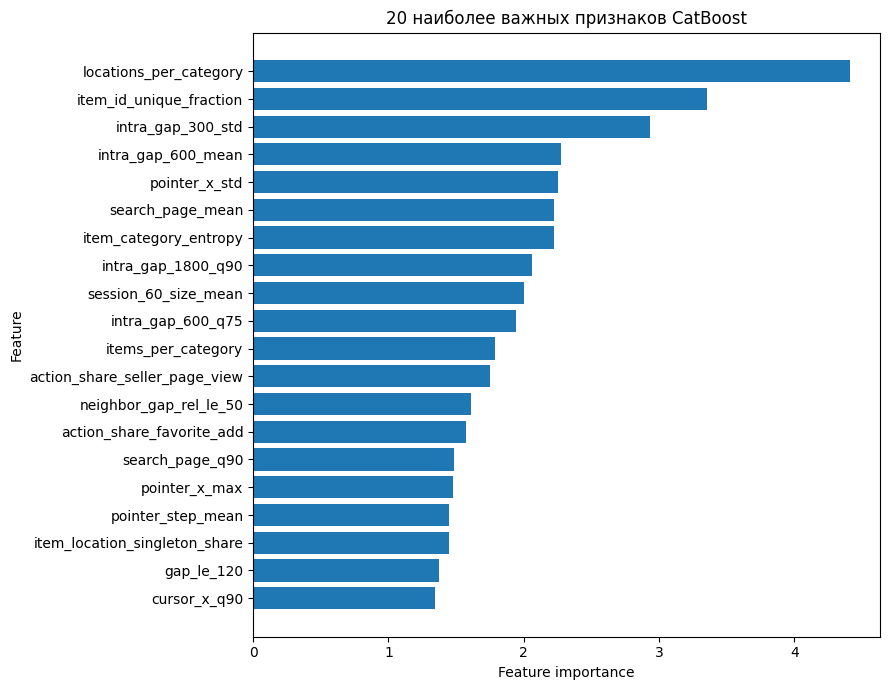

In [ ]:
import matplotlib.pyplot as plt

top_features = feature_importances.head(20).sort_values(
    "importance"
)

plt.figure(figsize=(9, 7))

plt.barh(
    top_features["feature"],
    top_features["importance"],
)

plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.title("20 наиболее важных признаков CatBoost")

plt.tight_layout()
plt.show()

## Проверка пепрвой версии модели

После выбора признаков и параметров модели второй период больше
не используется для настройки.

Для финальной локальной оценки модель переобучается на всех данных
до 17 апреля и проверяется на ранее не использованном периоде
17-19 апреля.


In [ ]:
pre_holdout_mask = (
    train_model["window_start_ts"] < pd.Timestamp("2026-04-17")
)

final_holdout_mask = (
    train_model["window_start_ts"] >= pd.Timestamp("2026-04-17")
)

print(
    "Обучение:",
    pre_holdout_mask.sum(),
    "| positives:",
    y[pre_holdout_mask].sum(),
)

print(
    "Holdout:",
    final_holdout_mask.sum(),
    "| positives:",
    y[final_holdout_mask].sum(),
)


holdout_predictions = []

for seed in ENSEMBLE_SEEDS:

    print(f"Обучение модели seed={seed}")

    model = CatBoostClassifier(
        **CATBOOST_PARAMS,
        random_seed=seed,
    )

    model.fit(
        X.loc[pre_holdout_mask],
        y.loc[pre_holdout_mask],
    )

    prediction = model.predict_proba(
        X.loc[final_holdout_mask]
    )[:, 1]

    holdout_predictions.append(prediction)


holdout_scores = np.mean(
    holdout_predictions,
    axis=0,
)

holdout_result = evaluate_predictions(
    y.loc[final_holdout_mask],
    holdout_scores,
    name="Final temporal holdout",
)

Обучение: 9140 | positives: 739
Holdout: 1951 | positives: 160
Обучение модели seed=42
Обучение модели seed=137
Обучение модели seed=2026
Final temporal holdout
Precision@Recall>=0.70: 0.8000
Average Precision:      0.7976
ROC-AUC:                0.9394


## Промежуточное обучение модели первой версии

После завершения локальной валидации параметры модели и набор признаков
фиксируются.

Для получения итоговых предсказаний три модели CatBoost обучала на всей
доступной размеченной выборке.

Для каждой cookie тестовой выборки каждая модель возвращает вероятность
класса `1`, после чего три вероятности усредняются.


In [ ]:
final_models = []
test_predictions = []

for seed in ENSEMBLE_SEEDS:

    print(f"Обучение финальной модели seed={seed}")

    model = CatBoostClassifier(
        **CATBOOST_PARAMS,
        random_seed=seed,
    )

    model.fit(
        X,
        y,
    )

    prediction = model.predict_proba(
        X_test
    )[:, 1]

    final_models.append(model)
    test_predictions.append(prediction)


# Усредняем вероятности трёх моделей.
final_test_scores = np.mean(
    test_predictions,
    axis=0,
)

print("Финальное обучение завершено.")
print("Количество предсказаний:", len(final_test_scores))
print("Минимальный score:", final_test_scores.min())
print("Максимальный score:", final_test_scores.max())

Обучение финальной модели seed=42
Обучение финальной модели seed=137
Обучение финальной модели seed=2026
Финальное обучение завершено.
Количество предсказаний: 4909
Минимальный score: 6.822679865316234e-05
Максимальный score: 0.9995879144794514


## Промежуточный результат первой версии

На скрытой тестовой выборке первый submission получил
`Precision@Recall>=0.70 ≈ 0.803`.

Далее я попыталась улучшить этот результат


## Улучшение модели

Первая версия показала, что агрегированные поведенческие признаки хорошо подходят для задачи. Однако набор из 128 признаков не полностью описывал структуру поведения внутри временного окна.

Поэтому следующим шагом я расширила признаковое пространство.Подробнее описала временной ритм и структуру сессий, поисковое поведение, разнообразие просматриваемых объектов, характеристики клиента и взаимодействие с интерфейсом.

Сначала строится широкий набор признаков-кандидатов, после чего наиболее полезная часть признаков выбирается отдельно на втором периоде.

### 1. Расширение набора признаков

In [ ]:
# Подготавливаем события для расширенного feature engineering
events_improved = events.copy()

raw_event_columns = events_improved.columns.tolist()

windows_improved = pd.concat([train[["cookie_id", "window_start_ts", "window_end_ts"]], test[["cookie_id", "window_start_ts", "window_end_ts"]]], ignore_index=True)

events_improved = events_improved.merge(windows_improved, on="cookie_id", how="left", validate="many_to_one")

inside_window = (events_improved["event_ts"] >= events_improved["window_start_ts"]) & (events_improved["event_ts"] < events_improved["window_end_ts"])
events_improved = events_improved.loc[inside_window].copy()

events_improved = events_improved.drop_duplicates(subset=raw_event_columns).copy()
events_improved = events_improved.sort_values(["cookie_id", "event_ts"]).reset_index(drop=True)

events_improved["platform_norm"] = events_improved["platform"].astype("string").str.lower().replace({"desktop": "web", "iphone": "ios"})
events_improved["time_diff_sec"] = events_improved.groupby("cookie_id")["event_ts"].diff().dt.total_seconds()

print("Событий после очистки:", len(events_improved))
print("Cookie:", events_improved["cookie_id"].nunique())
print("Отрицательных gap:", (events_improved["time_diff_sec"] < 0).sum())
print("Нулевых gap:", (events_improved["time_diff_sec"] == 0).sum())

Событий после очистки: 283833
Cookie: 16000
Отрицательных gap: 0
Нулевых gap: 1513


In [ ]:
import re
import unicodedata

# Вспомогательные функции для статистик разнообразия
def entropy_value(x):
    x = pd.Series(x).dropna()
    if len(x) == 0:
        return np.nan
    p = x.value_counts(normalize=True).values
    return -(p * np.log2(p)).sum()

def normalized_entropy(x):
    x = pd.Series(x).dropna()
    if len(x) == 0:
        return np.nan
    counts = x.value_counts()
    k = len(counts)
    if k <= 1:
        return 0.0
    p = counts.values / counts.sum()
    return -(p * np.log2(p)).sum() / np.log2(k)

def simpson_index(x):
    x = pd.Series(x).dropna()
    if len(x) == 0:
        return np.nan
    p = x.value_counts(normalize=True).values
    return np.sum(p ** 2)

def top_share(x):
    x = pd.Series(x).dropna()
    if len(x) == 0:
        return np.nan
    return x.value_counts(normalize=True).iloc[0]

def singleton_share(x):
    x = pd.Series(x).dropna()
    if len(x) == 0:
        return np.nan
    counts = x.value_counts()
    return (counts == 1).sum() / len(counts)

def unique_fraction(x):
    x = pd.Series(x).dropna()
    if len(x) == 0:
        return np.nan
    return x.nunique() / len(x)

# Относительный разброс числового признака
def numeric_cv(x):
    x = pd.to_numeric(pd.Series(x), errors="coerce").dropna()
    if len(x) == 0 or x.mean() == 0:
        return np.nan
    return x.std(ddof=0) / x.mean()

# Робастный относительный разброс
def mad_over_median(x):
    x = pd.to_numeric(pd.Series(x), errors="coerce").dropna()
    if len(x) == 0:
        return np.nan
    med = x.median()
    if med == 0:
        return np.nan
    return np.median(np.abs(x - med)) / med

# Нормализация поисковых запросов
def normalize_query(text):
    if pd.isna(text):
        return np.nan
    text = unicodedata.normalize("NFKC", str(text)).lower().replace("ё", "е")
    return re.sub(r"\s+", " ", text).strip()

In [ ]:
all_meta = pd.concat([train[["cookie_id", "cookie_created_at", "window_start_ts", "window_end_ts"]], test[["cookie_id", "cookie_created_at", "window_start_ts", "window_end_ts"]]], ignore_index=True)

features_improved = all_meta[["cookie_id"]].copy()
feature_frames = []

# Признаки возраста cookie
age = all_meta.copy()

age["cookie_age_start_days"] = (age["window_start_ts"] - age["cookie_created_at"]).dt.total_seconds() / 86400
age["cookie_age_end_days"] = (age["window_end_ts"] - age["cookie_created_at"]).dt.total_seconds() / 86400

first_event = events_improved.groupby("cookie_id")["event_ts"].min().rename("first_event_ts").reset_index()
age = age.merge(first_event, on="cookie_id", how="left")

age["cookie_age_first_event_days"] = (age["first_event_ts"] - age["cookie_created_at"]).dt.total_seconds() / 86400
age["created_inside_window"] = (age["cookie_created_at"] >= age["window_start_ts"]).astype(int)

age = age[["cookie_id", "cookie_age_start_days", "cookie_age_end_days", "cookie_age_first_event_days", "created_inside_window"]]
feature_frames.append(age)

In [ ]:
# Количество и доля каждого типа действия
action_counts = pd.crosstab(events_improved["cookie_id"], events_improved["event_name"])
action_counts.columns = [f"action_count_{x}" for x in action_counts.columns]
action_counts = action_counts.reset_index()

count_cols = [c for c in action_counts.columns if c != "cookie_id"]
action_counts["n_events"] = action_counts[count_cols].sum(axis=1)

for col in count_cols:
    name = col.replace("action_count_", "")
    action_counts[f"action_share_{name}"] = action_counts[col] / action_counts["n_events"]

# Разнообразие типов действий
event_entropy = events_improved.groupby("cookie_id")["event_name"].apply(entropy_value).rename("event_entropy").reset_index()
action_counts = action_counts.merge(event_entropy, on="cookie_id", how="left")

def get_action_col(name):
    col = f"action_count_{name}"
    if col in action_counts.columns:
        return action_counts[col]
    return pd.Series(0, index=action_counts.index)

item_views = get_action_col("item_view").replace(0, np.nan)
photo = get_action_col("photo_swipe")
favorite = get_action_col("favorite_add")
seller = get_action_col("seller_page_view")
phone = get_action_col("contact_phone_show")
chat = get_action_col("contact_chat_open")
message = get_action_col("contact_message_sent")
login = get_action_col("login")

# Число действий, связанных с контактом с продавцом
action_counts["contact_actions"] = phone + chat + message
# Число активных действий внутри объявления
action_counts["engagement_actions"] = photo + favorite + seller + phone + chat + message + login

# Доля отдельных действий на один просмотр объявления
action_counts["photo_per_item"] = photo / item_views
action_counts["favorite_per_item"] = favorite / item_views
action_counts["seller_per_item"] = seller / item_views
action_counts["contact_per_item"] = action_counts["contact_actions"] / item_views
# Доля активных взаимодействий среди всех событий cookie
action_counts["engagement_share"] = action_counts["engagement_actions"] / action_counts["n_events"]

feature_frames.append(action_counts)

### 2. Временные признаки

Кроме общего числа событий я добавила статистики интервалов между соседними действиями: средние значения, квантили, вариативность и доли коротких интервалов.

Отдельно рассматриваются интервалы внутри пользовательских сессий и регулярность соседних действий.

In [ ]:
# Основные статистики интервалов между соседними событиями
gap_group = events_improved.groupby("cookie_id")["time_diff_sec"]

timing = gap_group.agg(gap_count="count", gap_mean="mean", gap_std="std", gap_min="min", gap_max="max", gap_median="median").reset_index()

# Квантили и относительный разброс интервалов
gap_quantiles = gap_group.quantile([0.10, 0.25, 0.50, 0.75, 0.90, 0.95]).unstack().reset_index()
gap_quantiles.columns = ["cookie_id", "gap_q10", "gap_q25", "gap_q50", "gap_q75", "gap_q90", "gap_q95"]

timing = timing.merge(gap_quantiles, on="cookie_id", how="left")

extra_gap_stats = gap_group.agg(gap_cv=numeric_cv, gap_mad_over_median=mad_over_median).reset_index()
timing = timing.merge(extra_gap_stats, on="cookie_id", how="left")

timing["gap_iqr"] = timing["gap_q75"] - timing["gap_q25"]
timing["gap_iqr_over_median"] = timing["gap_iqr"] / timing["gap_median"].replace(0, np.nan)

# Доля коротких интервалов при разных временных порогах
gap_thresholds = [1, 2, 3, 5, 10, 30, 60, 120, 300, 600, 1800]
gap_source = events_improved[["cookie_id", "time_diff_sec"]].copy()

for threshold in gap_thresholds:
    tmp = gap_source.assign(flag=lambda d: d["time_diff_sec"] <= threshold).groupby("cookie_id")["flag"].mean().rename(f"gap_le_{threshold}").reset_index()
    timing = timing.merge(tmp, on="cookie_id", how="left")

zero_gap = events_improved.assign(zero_gap=events_improved["time_diff_sec"] == 0).groupby("cookie_id")["zero_gap"].mean().rename("zero_gap_share").reset_index()
timing = timing.merge(zero_gap, on="cookie_id", how="left")

# Общая продолжительность и интенсивность активности
activity = events_improved.groupby("cookie_id")["event_ts"].agg(first_event="min", last_event="max").reset_index()
activity["active_span_sec"] = (activity["last_event"] - activity["first_event"]).dt.total_seconds()

timing = timing.merge(activity[["cookie_id", "active_span_sec"]], on="cookie_id", how="left")

timing["events_per_active_hour"] = action_counts.set_index("cookie_id").reindex(timing["cookie_id"])["n_events"].values / (timing["active_span_sec"] / 3600).replace(0, np.nan)

feature_frames.append(timing)

In [ ]:
timing_extra = features_improved.copy()

# Статистики коротких интервалов и сессий при разных порогах
session_thresholds = [60, 120, 300, 600, 1800]

for threshold in session_thresholds:
    intra = events_improved.loc[events_improved["time_diff_sec"] <= threshold, ["cookie_id", "time_diff_sec"]]
    g = intra.groupby("cookie_id")["time_diff_sec"]

    stats = g.agg(**{f"intra_gap_{threshold}_count": "count", f"intra_gap_{threshold}_mean": "mean", f"intra_gap_{threshold}_std": "std", f"intra_gap_{threshold}_median": "median", f"intra_gap_{threshold}_min": "min", f"intra_gap_{threshold}_max": "max"}).reset_index()

    q = g.quantile([0.25, 0.75, 0.90]).unstack().reset_index()
    q.columns = ["cookie_id", f"intra_gap_{threshold}_q25", f"intra_gap_{threshold}_q75", f"intra_gap_{threshold}_q90"]

    robust = g.agg(**{f"intra_gap_{threshold}_cv": numeric_cv, f"intra_gap_{threshold}_mad_med": mad_over_median}).reset_index()

    timing_extra = timing_extra.merge(stats, on="cookie_id", how="left").merge(q, on="cookie_id", how="left").merge(robust, on="cookie_id", how="left")

    session_tmp = events_improved[["cookie_id", "time_diff_sec"]].copy()
    # Новый session_id начинается после паузы больше выбранного порога
    session_tmp["new_session"] = (session_tmp["time_diff_sec"].isna() | (session_tmp["time_diff_sec"] > threshold)).astype(int)
    session_tmp["session_id"] = session_tmp.groupby("cookie_id")["new_session"].cumsum()

    session_sizes = session_tmp.groupby(["cookie_id", "session_id"]).size().rename("session_size").reset_index()

    # Размер и количество сессий
    session_stats = session_sizes.groupby("cookie_id").agg(**{
        f"sessions_{threshold}_count": ("session_id", "nunique"),
        f"session_{threshold}_size_mean": ("session_size", "mean"),
        f"session_{threshold}_size_median": ("session_size", "median"),
        f"session_{threshold}_size_std": ("session_size", "std"),
        f"session_{threshold}_size_max": ("session_size", "max")
    }).reset_index()

    timing_extra = timing_extra.merge(session_stats, on="cookie_id", how="left")

# Регулярность соседних временных интервалов
regularity = events_improved[["cookie_id", "time_diff_sec"]].copy()
regularity["prev_gap"] = regularity.groupby("cookie_id")["time_diff_sec"].shift(1)
regularity["gap_difference"] = (regularity["time_diff_sec"] - regularity["prev_gap"]).abs()
regularity["relative_gap_difference"] = regularity["gap_difference"] / regularity[["time_diff_sec", "prev_gap"]].mean(axis=1).replace(0, np.nan)

# Доля соседних интервалов с небольшой абсолютной и относительной разницей
for seconds in [1, 2, 5, 10]:
    regularity[f"neighbor_gap_diff_le_{seconds}"] = regularity["gap_difference"] <= seconds

for fraction in [0.10, 0.20, 0.50]:
    name = int(fraction * 100)
    regularity[f"neighbor_gap_rel_le_{name}"] = regularity["relative_gap_difference"] <= fraction

reg_cols = [c for c in regularity.columns if c.startswith("neighbor_gap_")]
reg_features = regularity.groupby("cookie_id")[reg_cols].mean().reset_index()

timing_extra = timing_extra.merge(reg_features, on="cookie_id", how="left")
feature_frames.append(timing_extra)

### 3. Поисковое поведение

Для поисковых событий я использовала глубину просмотра выдачи, число и длину запросов, повторяемость запросов и последовательные переходы между страницами.

In [ ]:
search = events_improved.loc[events_improved["event_name"] == "search_results_view"].copy()

# Нормализуем запросы и считаем их длину
search["search_page_num"] = pd.to_numeric(search["search_page"], errors="coerce")
search["query_norm"] = search["search_query"].map(normalize_query)
search["query_length"] = search["query_norm"].fillna("").str.len()
search["query_words"] = search["query_norm"].fillna("").str.split().str.len()

# Количество поисков, разнообразие запросов и статистики страниц выдачи
search_features = search.groupby("cookie_id").agg(
    n_searches=("event_name", "size"),
    search_query_nunique=("query_norm", "nunique"),
    search_page_nunique=("search_page_num", "nunique"),
    search_page_mean=("search_page_num", "mean"),
    search_page_std=("search_page_num", "std"),
    search_page_median=("search_page_num", "median"),
    search_page_max=("search_page_num", "max"),
    query_length_mean=("query_length", "mean"),
    query_length_median=("query_length", "median"),
    query_length_max=("query_length", "max"),
    query_words_mean=("query_words", "mean"),
    query_words_median=("query_words", "median"),
    query_words_max=("query_words", "max")
).reset_index()

# Квантили глубины просмотра поисковой выдачи
search_q = search.groupby("cookie_id")["search_page_num"].quantile([0.25, 0.75, 0.90]).unstack().reset_index()
search_q.columns = ["cookie_id", "search_page_q25", "search_page_q75", "search_page_q90"]

search_features = search_features.merge(search_q, on="cookie_id", how="left")

# Доля уникальных и повторяющихся поисковых запросов
search_features["search_query_unique_fraction"] = search_features["search_query_nunique"] / search_features["n_searches"].replace(0, np.nan)
search_features["search_query_repeat_share"] = 1 - search_features["search_query_unique_fraction"]

# Доля поисков на глубоких страницах выдачи
for threshold in [5, 10]:
    tmp = search.assign(flag=search["search_page_num"] >= threshold).groupby("cookie_id")["flag"].mean().rename(f"search_page_ge_{threshold}_share").reset_index()
    search_features = search_features.merge(tmp, on="cookie_id", how="left")

# Сравниваем каждый поиск с предыдущим поиском того же cookie
search["prev_query"] = search.groupby("cookie_id")["query_norm"].shift()
search["prev_page"] = search.groupby("cookie_id")["search_page_num"].shift()

# Повтор одного запроса подряд и последовательный переход на следующую страницу
search["same_query_consecutive"] = search["query_norm"].notna() & (search["query_norm"] == search["prev_query"])
search["next_page_same_query"] = search["same_query_consecutive"] & (search["search_page_num"] == search["prev_page"] + 1)

# Доли последовательного поведения в поисковой выдаче
pagination = search.groupby("cookie_id").agg(same_query_consecutive_share=("same_query_consecutive", "mean"), next_page_same_query_share=("next_page_same_query", "mean")).reset_index()

search_features = search_features.merge(pagination, on="cookie_id", how="left")
feature_frames.append(search_features)

### 4. Разнообразие объектов

Для каждого cookie я отдельно описала разнообразие объявлений, категорий, локаций и типов продавцов. Используются число уникальных значений, энтропия, концентрация и доля редких значений.

In [ ]:
diversity = features_improved.copy()
# Разнообразие объявлений, категорий, локаций и типов продавца
div_cols = ["item_id", "item_category", "item_location", "seller_type"]

# Для каждого типа объекта считаем число уникальных значений, концентрацию и равномерность распределения
for col in div_cols:
    source = events_improved.loc[events_improved[col].notna(), ["cookie_id", col]]
    g = source.groupby("cookie_id")[col]

    basic = g.agg(**{
        f"{col}_observed": "size",
        f"{col}_nunique": "nunique",
        f"{col}_top_share": top_share,
        f"{col}_unique_fraction": unique_fraction,
        f"{col}_entropy": entropy_value,
        f"{col}_normalized_entropy": normalized_entropy,
        f"{col}_simpson": simpson_index,
        f"{col}_singleton_share": singleton_share
    }).reset_index()

    diversity = diversity.merge(basic, on="cookie_id", how="left")

# Отношения количества объектов, категорий и локаций
diversity["items_per_category"] = diversity["item_id_nunique"] / diversity["item_category_nunique"].replace(0, np.nan)
diversity["locations_per_category"] = diversity["item_location_nunique"] / diversity["item_category_nunique"].replace(0, np.nan)
diversity["locations_per_item"] = diversity["item_location_nunique"] / diversity["item_id_nunique"].replace(0, np.nan)

feature_frames.append(diversity)

### 5. Платформа и User-Agent

Сырые User-Agent строки напрямую в модель не передаются. Вместо этого используются числовые признаки: число разных User-Agent, платформа и доли технических признаков в строке клиента.

In [ ]:
# Технические признаки платформы и User-Agent
device = events_improved[["cookie_id", "platform_norm", "user_agent"]].copy()
ua = device["user_agent"].fillna("").str.lower()

# Флаги мобильного клиента, ОС, приложения и HTTP-библиотек
device["ua_headless"] = ua.str.contains("headless")
device["ua_http_library"] = ua.str.contains("okhttp|curl|wget|python-requests|aiohttp", regex=True)
device["ua_mobile"] = ua.str.contains("android|iphone|mobile", regex=True)
device["ua_avito_app"] = ua.str.contains("avito/")
device["ua_windows"] = ua.str.contains("windows")
device["ua_android"] = ua.str.contains("android")
device["ua_ios"] = ua.str.contains("iphone|ipad|ios", regex=True)
device["ua_linux"] = ua.str.contains("linux") & ~device["ua_android"]

# Доля событий с каждым типом User-Agent
device_features = device.groupby("cookie_id").agg(
    user_agent_nunique=("user_agent", "nunique"),
    platform_nunique=("platform_norm", "nunique"),
    ua_headless_share=("ua_headless", "mean"),
    ua_http_library_share=("ua_http_library", "mean"),
    ua_mobile_share=("ua_mobile", "mean"),
    ua_avito_app_share=("ua_avito_app", "mean"),
    ua_windows_share=("ua_windows", "mean"),
    ua_android_share=("ua_android", "mean"),
    ua_ios_share=("ua_ios", "mean"),
    ua_linux_share=("ua_linux", "mean")
).reset_index()

# Доля событий по платформам
platform_share = pd.crosstab(device["cookie_id"], device["platform_norm"], normalize="index").add_prefix("platform_share_").reset_index()

device_features = device_features.merge(platform_share, on="cookie_id", how="left")
feature_frames.append(device_features)

### 6. Координаты курсора

Для событий с координатами я рассчитала распределение X/Y, область покрытия, расстояния между последовательными точками и разнообразие пространственных областей.

Для расчёта движения используются только пары точек с увеличившимся timestamp.

In [ ]:
# Оставляем только события с валидными координатами курсора
events_improved["pointer_x_num"] = pd.to_numeric(events_improved["pointer_x"], errors="coerce")
events_improved["pointer_y_num"] = pd.to_numeric(events_improved["pointer_y"], errors="coerce")
events_improved["pointer_valid"] = events_improved["pointer_x_num"].notna() & events_improved["pointer_y_num"].notna()

pointer = events_improved.loc[events_improved["pointer_valid"], ["cookie_id", "event_ts", "pointer_x_num", "pointer_y_num"]].copy()

# Основные статистики положения курсора по осям X и Y
pointer_basic = pointer.groupby("cookie_id").agg(
    pointer_count=("pointer_x_num", "size"),
    pointer_x_mean=("pointer_x_num", "mean"),
    pointer_x_std=("pointer_x_num", "std"),
    pointer_x_min=("pointer_x_num", "min"),
    pointer_x_max=("pointer_x_num", "max"),
    pointer_x_median=("pointer_x_num", "median"),
    pointer_y_mean=("pointer_y_num", "mean"),
    pointer_y_std=("pointer_y_num", "std"),
    pointer_y_min=("pointer_y_num", "min"),
    pointer_y_max=("pointer_y_num", "max"),
    pointer_y_median=("pointer_y_num", "median")
).reset_index()

pointer_features = pointer_basic.copy()

# Квантили координат курсора
for axis in ["x", "y"]:
    col = f"pointer_{axis}_num"
    q = pointer.groupby("cookie_id")[col].quantile([0.10, 0.25, 0.75, 0.90]).unstack().reset_index()
    q.columns = ["cookie_id", f"cursor_{axis}_q10", f"cursor_{axis}_q25", f"cursor_{axis}_q75", f"cursor_{axis}_q90"]
    pointer_features = pointer_features.merge(q, on="cookie_id", how="left")

# Размах и площадь области движения курсора
pointer_features["cursor_x_range"] = pointer_features["pointer_x_max"] - pointer_features["pointer_x_min"]
pointer_features["cursor_y_range"] = pointer_features["pointer_y_max"] - pointer_features["pointer_y_min"]
pointer_features["cursor_bbox_area"] = pointer_features["cursor_x_range"] * pointer_features["cursor_y_range"]

# Устойчивый разброс координат относительно медианы
pointer_features["cursor_x_iqr"] = pointer_features["cursor_x_q75"] - pointer_features["cursor_x_q25"]
pointer_features["cursor_y_iqr"] = pointer_features["cursor_y_q75"] - pointer_features["cursor_y_q25"]

pointer_features["cursor_x_iqr_ratio"] = pointer_features["cursor_x_iqr"] / pointer_features["pointer_x_median"].abs().replace(0, np.nan)
pointer_features["cursor_y_iqr_ratio"] = pointer_features["cursor_y_iqr"] / pointer_features["pointer_y_median"].abs().replace(0, np.nan)

In [ ]:
# Доля web-событий, для которых доступны координаты курсора
web_events = events_improved["platform_norm"] == "web"

web_counts = events_improved.loc[web_events].groupby("cookie_id").size().rename("web_event_count")
web_pointer_counts = events_improved.loc[web_events & events_improved["pointer_valid"]].groupby("cookie_id").size().rename("web_pointer_count")

coverage = pd.concat([web_counts, web_pointer_counts], axis=1).reset_index()
coverage["web_pointer_presence_share"] = coverage["web_pointer_count"] / coverage["web_event_count"]

pointer_features = pointer_features.merge(coverage, on="cookie_id", how="outer")

# Расстояние между соседними положениями курсора
pointer["prev_x"] = pointer.groupby("cookie_id")["pointer_x_num"].shift()
pointer["prev_y"] = pointer.groupby("cookie_id")["pointer_y_num"].shift()
pointer["prev_ts"] = pointer.groupby("cookie_id")["event_ts"].shift()

strict_step = pointer["prev_ts"].notna() & (pointer["event_ts"] > pointer["prev_ts"])

pointer["pointer_dx"] = np.where(strict_step, (pointer["pointer_x_num"] - pointer["prev_x"]).abs(), np.nan)
pointer["pointer_dy"] = np.where(strict_step, (pointer["pointer_y_num"] - pointer["prev_y"]).abs(), np.nan)
pointer["pointer_step"] = np.sqrt(pointer["pointer_dx"] ** 2 + pointer["pointer_dy"] ** 2)

step_group = pointer.groupby("cookie_id")["pointer_step"]

# Статистики размера перемещения курсора
step_stats = step_group.agg(pointer_step_mean="mean", pointer_step_std="std", pointer_step_median="median", pointer_step_max="max").reset_index()

step_quantiles = step_group.quantile([0.25, 0.75, 0.90]).unstack().reset_index()
step_quantiles.columns = ["cookie_id", "pointer_step_p25", "pointer_step_p75", "pointer_step_p90"]

pointer_features = pointer_features.merge(step_stats, on="cookie_id", how="left").merge(step_quantiles, on="cookie_id", how="left")

In [ ]:
# Делим пространство координат на области 100x100
pointer["cell_x"] = pointer["pointer_x_num"] // 100
pointer["cell_y"] = pointer["pointer_y_num"] // 100
pointer["spatial_cell"] = pointer["cell_x"].astype(str) + "_" + pointer["cell_y"].astype(str)

# Разнообразие областей экрана, в которых находился курсор
cell_features = pointer.groupby("cookie_id")["spatial_cell"].agg(
    spatial_cell_nunique="nunique",
    spatial_cell_entropy=entropy_value,
    spatial_cell_top_share=top_share,
    spatial_cell_singleton_share=singleton_share
).reset_index()

pointer_features = pointer_features.merge(cell_features, on="cookie_id", how="left")

# Асимметрия и эксцесс распределения координат
shape_features = pointer.groupby("cookie_id").agg(
    cursor_x_skew=("pointer_x_num", "skew"),
    cursor_y_skew=("pointer_y_num", "skew"),
    cursor_x_kurt=("pointer_x_num", lambda x: x.kurt()),
    cursor_y_kurt=("pointer_y_num", lambda x: x.kurt())
).reset_index()

pointer_features = pointer_features.merge(shape_features, on="cookie_id", how="left")
feature_frames.append(pointer_features)

# Объединяем все группы признаков в одну таблицу
for frame in feature_frames:
    features_improved = features_improved.merge(frame, on="cookie_id", how="left", validate="one_to_one")

features_improved = features_improved.replace([np.inf, -np.inf], np.nan)

print("Features shape:", features_improved.shape)
print("Number of model features:", features_improved.shape[1] - 1)
print("Duplicate cookie_id:", features_improved["cookie_id"].duplicated().sum())
print("Missing cookies:", len(train) + len(test) - len(features_improved))

Features shape: (16000, 263)
Number of model features: 262
Duplicate cookie_id: 0
Missing cookies: 0


## Отбор признаков

Расширенный набор содержит 262 признака. Не все из них одинаково полезны, поэтому сначала я обучила CatBoost на development-разбиении и оценила важность признаков.

Важность усредняется по трём моделям с разными random seed. Затем проверяется несколько размеров набора наиболее важных признаков.

In [ ]:
from sklearn.metrics import average_precision_score, roc_auc_score
from catboost import CatBoostClassifier

model_data = train[["cookie_id", "window_start_ts", "target"]].merge(features_improved, on="cookie_id", how="left", validate="one_to_one")

feature_cols = [col for col in features_improved.columns if col != "cookie_id"]

X_all = model_data[feature_cols].copy().replace([np.inf, -np.inf], np.nan).fillna(-999)
y_all = model_data["target"].astype(int).copy()

train_mask = model_data["window_start_ts"] < pd.Timestamp("2026-04-13")
dev_mask = (model_data["window_start_ts"] >= pd.Timestamp("2026-04-13")) & (model_data["window_start_ts"] < pd.Timestamp("2026-04-17"))
holdout_mask = (model_data["window_start_ts"] >= pd.Timestamp("2026-04-17")) & (model_data["window_start_ts"] < pd.Timestamp("2026-04-20"))

print("Number of features:", len(feature_cols))
print("TRAIN:", train_mask.sum(), "bots:", y_all.loc[train_mask].sum())
print("DEV:", dev_mask.sum(), "bots:", y_all.loc[dev_mask].sum())
print("HOLDOUT:", holdout_mask.sum(), "bots:", y_all.loc[holdout_mask].sum())

In [ ]:
MODEL_PARAMS = {"iterations": 1200, "depth": 5, "learning_rate": 0.04, "l2_leaf_reg": 5, "loss_function": "Logloss", "verbose": False, "thread_count": -1}

dev_predictions = []
dev_models = []

for seed in ENSEMBLE_SEEDS:
    model = CatBoostClassifier(**MODEL_PARAMS, random_seed=seed)
    model.fit(X_all.loc[train_mask], y_all.loc[train_mask])

    pred = model.predict_proba(X_all.loc[dev_mask])[:, 1]
    dev_predictions.append(pred)
    dev_models.append(model)

    print(f"seed={seed} P@R>=0.7 =", round(precision_at_recall(y_all.loc[dev_mask], pred), 4))

dev_pred_ensemble = np.mean(dev_predictions, axis=0)

print()
print("DEV ENSEMBLE")
print("P@Recall>=0.7:", round(precision_at_recall(y_all.loc[dev_mask], dev_pred_ensemble), 4))
print("PR-AUC:", round(average_precision_score(y_all.loc[dev_mask], dev_pred_ensemble), 4))
print("ROC-AUC:", round(roc_auc_score(y_all.loc[dev_mask], dev_pred_ensemble), 4))

In [ ]:
importance_list = []

for seed in ENSEMBLE_SEEDS:
    model_imp = CatBoostClassifier(**MODEL_PARAMS, random_seed=seed)
    model_imp.fit(X_all.loc[train_mask], y_all.loc[train_mask])
    importance_list.append(model_imp.get_feature_importance())

mean_importance = np.mean(importance_list, axis=0)
std_importance = np.std(importance_list, axis=0)

feature_importance = pd.DataFrame({"feature": feature_cols, "importance_mean": mean_importance, "importance_std": std_importance})
feature_importance = feature_importance.sort_values("importance_mean", ascending=False).reset_index(drop=True)

feature_importance["cumulative_importance"] = feature_importance["importance_mean"].cumsum() / feature_importance["importance_mean"].sum()

display(feature_importance.head(30))
print("Total features:", len(feature_importance))

,feature,importance_mean,importance_std,cumulative_importance
0,locations_per_category,4.040168,0.125020,0.040402
1,item_id_unique_fraction,2.319885,0.156595,0.063601
2,item_category_entropy,1.759351,0.268666,0.081194
3,items_per_category,1.593601,0.117174,0.097130
4,cursor_x_q90,1.536722,0.458288,0.112497
5,neighbor_gap_diff_le_10,1.536117,0.245466,0.127858
6,pointer_x_std,1.508990,0.239403,0.142948
7,pointer_step_max,1.463426,0.192260,0.157583
8,pointer_y_max,1.207231,0.067131,0.169655
9,pointer_x_max,1.170218,0.532963,0.181357


Total features: 262


Среди наиболее важных признаков неожиданно высоко оказались новые характеристики разнообразия объектов, движения курсора и регулярности временных интервалов. Это говорит о том, что расширенный feature engineering добавил модели полезную информацию, которой не было в первой версии.

### Выбор количества признаков

Я проверила несколько размеров top-N набора по усреднённой feature importance. holdout 17-19 апреля на этом этапе не используется: количество признаков выбирается только по второй выборке 13-16 апреля.

In [57]:
candidate_sizes = [50, 100, 150, 200, 250, 300, len(feature_cols)]
candidate_sizes = sorted(set(min(n, len(feature_cols)) for n in candidate_sizes))

feature_selection_results = []

for n_features in candidate_sizes:
    selected = feature_importance.head(n_features)["feature"].tolist()
    seed_predictions = []

    for seed in ENSEMBLE_SEEDS:
        model_fs = CatBoostClassifier(**MODEL_PARAMS, random_seed=seed)
        model_fs.fit(X_all.loc[train_mask, selected], y_all.loc[train_mask])
        pred = model_fs.predict_proba(X_all.loc[dev_mask, selected])[:, 1]
        seed_predictions.append(pred)

    pred_ensemble = np.mean(seed_predictions, axis=0)

    feature_selection_results.append({
        "n_features": n_features,
        "P@R>=0.7": precision_at_recall(y_all.loc[dev_mask], pred_ensemble),
        "PR_AUC": average_precision_score(y_all.loc[dev_mask], pred_ensemble),
        "ROC_AUC": roc_auc_score(y_all.loc[dev_mask], pred_ensemble)
    })

feature_selection_results = pd.DataFrame(feature_selection_results).sort_values("P@R>=0.7", ascending=False)
display(feature_selection_results)

,n_features,P@R>=0.7,PR_AUC,ROC_AUC
1,100,0.759825,0.792962,0.947180
5,262,0.746781,0.788352,0.944105
2,150,0.737288,0.789095,0.944892
3,200,0.736402,0.790199,0.945241
4,250,0.716049,0.789411,0.944855
0,50,0.679688,0.779505,0.939855


In [58]:
best_dev_score = feature_selection_results["P@R>=0.7"].max()

acceptable = feature_selection_results[feature_selection_results["P@R>=0.7"] >= best_dev_score - 0.005]

BEST_N_FEATURES = int(acceptable["n_features"].min())
SELECTED_FEATURES = feature_importance.head(BEST_N_FEATURES)["feature"].tolist()

print("Best development score:", best_dev_score)
print("Selected number of features:", BEST_N_FEATURES)
print("Selected features:")
print(SELECTED_FEATURES)

Best development score: 0.759825327510917
Selected number of features: 100
Selected features:
['locations_per_category', 'item_id_unique_fraction', 'item_category_entropy', 'items_per_category', 'cursor_x_q90', 'neighbor_gap_diff_le_10', 'pointer_x_std', 'pointer_step_max', 'pointer_y_max', 'pointer_x_max', 'session_60_size_mean', 'action_share_seller_page_view', 'neighbor_gap_diff_le_1', 'pointer_step_mean', 'gap_le_30', 'cookie_age_first_event_days', 'item_location_singleton_share', 'search_page_median', 'item_id_normalized_entropy', 'item_id_singleton_share', 'item_category_nunique', 'intra_gap_300_std', 'action_share_favorite_add', 'cursor_bbox_area', 'search_page_mean', 'neighbor_gap_rel_le_50', 'search_page_q90', 'pointer_step_median', 'item_location_unique_fraction', 'action_share_search_results_view', 'seller_per_item', 'item_location_normalized_entropy', 'intra_gap_600_q75', 'engagement_share', 'contact_per_item', 'photo_per_item', 'intra_gap_1800_q90', 'cookie_age_start_days'

## Финальная временная проверка

После выбора конфигурации я один раз проверила её на более позднем периоде 17-19 апреля. Для этого модели переобучаются только на данных до 17 апреля.

In [59]:
pre_holdout_mask = model_data["window_start_ts"] < pd.Timestamp("2026-04-17")

holdout_predictions = []

for seed in ENSEMBLE_SEEDS:
    model_holdout = CatBoostClassifier(**MODEL_PARAMS, random_seed=seed)
    model_holdout.fit(X_all.loc[pre_holdout_mask, SELECTED_FEATURES], y_all.loc[pre_holdout_mask])

    pred = model_holdout.predict_proba(X_all.loc[holdout_mask, SELECTED_FEATURES])[:, 1]
    holdout_predictions.append(pred)

holdout_pred = np.mean(holdout_predictions, axis=0)

holdout_p = precision_at_recall(y_all.loc[holdout_mask], holdout_pred)
holdout_pr = average_precision_score(y_all.loc[holdout_mask], holdout_pred)
holdout_roc = roc_auc_score(y_all.loc[holdout_mask], holdout_pred)

print("FINAL HOLDOUT 17-19 APRIL")
print("P@Recall>=0.7:", round(holdout_p, 4))
print("PR-AUC:", round(holdout_pr, 4))
print("ROC-AUC:", round(holdout_roc, 4))

FINAL HOLDOUT 17-19 APRIL
P@Recall>=0.7: 0.8
PR-AUC: 0.7885
ROC-AUC: 0.9391


## Финальное обучение и формирование итогового сабмита

После выбора набора из 100 признаков и проверки на последнем временном периоде три CatBoost переобучаются на всей размеченной выборке. Итоговый score получается усреднением их вероятностей.

In [60]:
test_model_data = test[["cookie_id", "window_start_ts"]].merge(features_improved, on="cookie_id", how="left", validate="one_to_one")

X_test_final = test_model_data[SELECTED_FEATURES].copy().replace([np.inf, -np.inf], np.nan).fillna(-999)

print("Test shape:", X_test_final.shape)

Test shape: (4909, 100)


In [61]:
final_models = []
test_predictions = []

for seed in ENSEMBLE_SEEDS:
    print("Final seed:", seed)

    final_model = CatBoostClassifier(**MODEL_PARAMS, random_seed=seed)
    final_model.fit(X_all[SELECTED_FEATURES], y_all)

    pred_test = final_model.predict_proba(X_test_final)[:, 1]

    final_models.append(final_model)
    test_predictions.append(pred_test)

final_test_score = np.mean(test_predictions, axis=0)

print("Min prediction:", final_test_score.min())
print("Max prediction:", final_test_score.max())

Final seed: 42
Final seed: 137
Final seed: 2026
Min prediction: 1.915692859607589e-05
Max prediction: 0.999801391089017


In [62]:
submission = pd.DataFrame({"cookie_id": test_model_data["cookie_id"], "score": final_test_score})

display(submission.head())
print(submission.shape)

,cookie_id,score
0,ck_315fb710a0e371e7,0.000177
1,ck_a76ee3b3e3e522fd,0.033029
2,ck_94c9a4d382689e82,0.062561
3,ck_8eaf9509ad9462a0,0.000685
4,ck_9a88a5a989cb5bc6,0.007988


(4909, 2)


In [63]:
assert list(submission.columns) == ["cookie_id", "score"]
assert len(submission) == len(test)
assert submission["cookie_id"].is_unique
assert submission["score"].notna().all()
assert submission["score"].between(0, 1).all()
assert submission["cookie_id"].tolist() == test["cookie_id"].tolist()

submission.to_csv("submission.csv", index=False)

print("Rows:", len(submission))
print("Saved: submission.csv")

Rows: 4909
Saved: submission.csv


## Итоги

В работе была построена модель для выявления автоматизированного трафика по поведенческим событиям cookie.

Сначала была обучена базовая версия CatBoost на компактном наборе агрегированных признаков. Затем признаковое пространство было расширено до 262 признаков-кандидатов, описывающих:

- временной ритм и структуру сессий;
- поисковое поведение;
- разнообразие объявлений, категорий и локаций;
- характеристики платформы и User-Agent;
- поведение курсора.

Так как использование всех признаков не дало наилучшего результата, был проведён отбор по feature importance CatBoost. Лучшее качество на втором периоде показал набор из 100 наиболее важных признаков:

`Precision@Recall>=0.70 = 0.7598`.

На финальном временном holdout 17-19 апреля выбранная конфигурация получила:

- `Precision@Recall>=0.70 = 0.8000`;
- `PR-AUC = 0.7885`;
- `ROC-AUC = 0.9391`.

Финальная модель представляет собой ансамбль из трёх CatBoost с разными random seed. После фиксации конфигурации модели были переобучены на всей обучающей выборке, а их вероятности усреднены для получения итогового score.

На скрытой тестовой выборке итоговый submission получил:

`Precision@Recall>=0.70 = 0.83077`.

Что улучшило предыдущий результат примерно на 0.03